# DAI Mission: Proposal & Final Submission
**Data & AI in Economics | TU Dortmund**

This notebook is the team's mission proposal, extended into the final deliverable.

> **Team size:** 3 students
> **Deliverable:** This Jupyter Notebook (proposal → final submission in one file)


## 1. Team

| Role | Name | Student ID |
|------|------|------------|
| Lead | Usama Saleem | |
| Member | Zi Zhang | |
| Member | Ekin Yuecesan | |


## 2. Mission Title & Research Question

**Title:** Predicting Corporate Financial Distress from Accounting Ratios: A Causal ML Approach

**Research question:**
Can machine learning models trained on Compustat financial statement ratios predict corporate financial distress within a horizon of one year more accurately than the classical Altman Z score, and to what extent does leverage *causally* increase distress probability rather than merely correlating with it?

**Why it matters:**
Corporate default imposes severe costs on creditors, employees, and the broader economy. Banks, rating agencies, and credit funds rely on distress models to price loans, set credit limits, and allocate capital. The classical Altman Z score (1968) uses five ratios chosen by hand, but modern ML can search across many ratios simultaneously and capture nonlinear interactions between them. Critically, high leverage predicts default, but does it *cause* it? A firm in trouble often borrows to survive, and firms with better access to credit (larger, more profitable firms) also tend to carry more long term debt while being inherently safer. Leverage's relationship with distress is confounded. Understanding this distinction matters for regulatory policy and for fair model design. This project combines causal inference, supervised learning, and unsupervised learning on the same financial dataset.


## 3. Data

**Source(s):**
Compustat North America (Fundamentals Annual), accessed via WRDS (Wharton Research Data Services), TU Dortmund institutional access. Usage is governed by the WRDS/Compustat data licence and is not for redistribution outside the research team.

**Unit of observation:** One row = one firm fiscal year (identified by `gvkey` + `fyear`).

**Key variables:**

| Variable | Type | Role | Description |
|----------|------|------|--------------|
| `gvkey` | id | identifier | Compustat firm identifier |
| `fyear` | int | identifier | Fiscal year (derived from `datadate`) |
| `at` | float | feature input | Total assets |
| `act` | float | feature input | Current assets |
| `lct` | float | feature input | Current liabilities |
| `lt` | float | feature input | Total liabilities |
| `dltt` | float | feature input | Long term debt |
| `revt` | float | feature input | Total revenue |
| `ebit` / `ebitda` | float | feature input | Earnings before interest & tax / before interest, tax, depreciation & amortization |
| `ni` | float | feature input | Net income |
| `xint` | float | feature input | Interest expense |
| `ceq` | float | label driver | Common/book equity |
| `wcap`, `re` | float | feature input | Working capital, retained earnings |
| `sic` / `sich` | categorical | filter | Current / historical industry classification |
| `costat` | categorical | examined, not used | Compustat active/inactive flag |
| `distress` (engineered) | binary | **target** | 1 if firm transitions into distress next year |

**Potential data quality issues (identified and handled below):**
Negative current assets and negative revenue (impossible values), EBIT exceeding EBITDA (impossible if D&A ≥ 0), firms below the $1M total assets threshold (shell companies / data errors), fiscal year end changes that create not comparable "stub period" years, extreme asset jumps from one year to the next (M&A vs. data errors), missing values in core variables, and a label persistence issue where firms already distressed in year *t* would otherwise be double counted as "new" distress in year *t+1*.


## Cell 1. Imports

In [1]:
import warnings, os
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.inspection import permutation_importance
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report,
                              confusion_matrix, accuracy_score, f1_score,
                              precision_recall_curve, average_precision_score)
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
print("Imports successful")

Imports successful


## Cell 2. Load Raw Data
The fiscal year (`fyear`) isn't a column in the raw pull; it is derived
from `datadate`, the fiscal period end date Compustat actually reports.

In [2]:
df = pd.read_csv("data/compustat_raw.csv", low_memory=False)
df["datadate"] = pd.to_datetime(df["datadate"])
df["fyear"] = df["datadate"].dt.year
print("Raw shape:", df.shape)
print("Years:", df.fyear.min(), "to", df.fyear.max())
print("Unique firms:", df.gvkey.nunique())

Raw shape: (220729, 25)
Years: 2000 to 2022
Unique firms: 25056


## Cell 3. Initial Filtering

**Fix applied here:** industry classification now uses `sich` (the
*historical* SIC code Compustat assigns for that specific fiscal year),
falling back to current `sic` only when `sich` is missing. This matters
because a firm's business can change over a panel spanning 22 years (e.g. a
conglomerate that exits manufacturing for financial services); using only
today's `sic` would misclassify its industry in earlier years. We checked:
**74,798 rows (34%)** have `sic` not equal to `sich`, confirming this is a real,
not cosmetic, distinction.

Standard academic finance filters beyond that: drop duplicate firm years,
exclude financial firms (SIC 6000 to 6999, different accounting rules) and
utilities (SIC 4900 to 4999, regulated capital structure), restrict to
2000 to 2022.

In [3]:
def initial_filter(df):
    n0 = len(df)
    df = df.copy()
    df["sich"] = df["sich"].fillna(df["sic"])
    df = df[(df["fyear"] >= 2000) & (df["fyear"] <= 2022)]
    df = df[~df["sich"].between(6000, 6999)]
    df = df[~df["sich"].between(4900, 4999)]
    df = df.drop_duplicates(subset=["gvkey", "fyear"], keep="first")
    n1 = len(df)
    print(f"Rows before: {n0:,}  after: {n1:,}  removed: {n0-n1:,}")
    print(f"Unique firms remaining: {df['gvkey'].nunique():,}")
    return df

df = initial_filter(df)

Rows before: 220,729  after: 137,470  removed: 83,259
Unique firms remaining: 16,107


## Cell 4. Total Assets and Impossible Value Cleaning

**What this does:** drops rows that are either too small to be a real
operating business, or contain values that are mathematically
impossible, meaning they are data errors, not just unusual firms.

Four checks, applied in sequence:

- **Total assets**: drops rows where `at` is missing, zero, negative, or
  under $1M. There is no single universal threshold in the distress
  prediction literature; studies vary widely in how they define a
  minimum firm size, and some use no minimum at all, others use revenue
  or employee count instead of total assets, and others restrict to
  manufacturing firms with no formal floor. The $1M total assets floor
  used here is a practical choice for this dataset specifically: rows
  this small in Compustat are almost always either shell companies with
  no real operations or data entry errors rather than genuine small
  businesses, since most operating companies large enough to be covered
  by Compustat in the first place report total assets well above this
  level. Excluding them keeps the sample focused on real operating
  firms without imposing a much stricter size cutoff that would also
  remove legitimate small caps.
- **Negative current assets** (`act < 0`): impossible, since current assets
  (cash, receivables, inventory) cannot be negative.
- **Negative revenue** (`revt < 0`): also impossible for normal
  operating revenue, almost certainly a restatement or reporting artifact.
- **EBIT > EBITDA**: impossible if depreciation and amortization is
  not negative, since EBIT equals EBITDA minus D&A. We found 6 rows violating
  this, one with a 3,248 unit gap, a clear data entry error.

Each step prints how many rows it removed, and the function prints the
final shape of the dataframe so the cumulative effect of all four checks
is visible.

In [4]:
def clean_impossible_values(df):
    n0 = len(df)
    df = df[df["at"].notna() & (df["at"] >= 1)]
    n_assets = n0 - len(df)

    n1 = len(df)
    df = df[~(df["act"] < 0)]
    n_act = n1 - len(df)

    n2 = len(df)
    df = df[~(df["revt"] < 0)]
    n_revt = n2 - len(df)

    n3 = len(df)
    ebit_violation = df["ebit"].notna() & df["ebitda"].notna() & (df["ebit"] > df["ebitda"])
    df = df[~ebit_violation]
    n_ebit = n3 - len(df)

    print(f"Dropped for total assets (NaN/0/neg/<$1M): {n_assets:,}")
    print(f"Dropped for negative current assets (act<0): {n_act:,}")
    print(f"Dropped for negative revenue (revt<0): {n_revt:,}")
    print(f"Dropped for EBIT > EBITDA (impossible if D&A>=0): {n_ebit:,}")
    print(f"Shape after: {df.shape}")
    return df

df = clean_impossible_values(df)

Dropped for total assets (NaN/0/neg/<$1M): 13,068
Dropped for negative current assets (act<0): 7
Dropped for negative revenue (revt<0): 26
Dropped for EBIT > EBITDA (impossible if D&A>=0): 6
Shape after: (124363, 25)


## Cell 5. Fiscal Year End Change Detection

**999 firms changed their fiscal year end month (`fyr`) at least once**
across the panel. The transition year for these firms has a "stub
period", often shorter or longer than 12 months, which makes that
year's flow variables (`revt`, `ebitda`, `ni`, `xint`) not comparable
to a normal twelve month fiscal year. A six month "ebitda" would look like a
profit collapse next to a normal year's twelve month figure, purely from the
period length, not from any real change in the business.

**Fix:** flag the specific transition firm year, then exclude just that
one row; the firm itself stays in the panel, only its distorted
transition year is removed.

In [5]:
def flag_and_exclude_fyr_changes(df):
    df = df.sort_values(["gvkey", "fyear"]).copy()
    df["fyr_prev"] = df.groupby("gvkey")["fyr"].shift(1)
    df["fyr_change_flag"] = ((df["fyr_prev"].notna()) & (df["fyr"] != df["fyr_prev"])).astype(int)

    n_flagged = df["fyr_change_flag"].sum()
    n_firms_affected = df.loc[df["fyr_change_flag"]==1, "gvkey"].nunique()
    print(f"Fiscal year end transition years flagged: {n_flagged:,} ({n_firms_affected:,} firms affected)")

    n_before = len(df)
    df = df[df["fyr_change_flag"] == 0].copy()
    print(f"Excluded (stub period transition years only, firms kept): {n_before - len(df):,}")
    df = df.drop(columns=["fyr_prev", "fyr_change_flag"])
    return df

df = flag_and_exclude_fyr_changes(df)

Fiscal year end transition years flagged: 628 (613 firms affected)
Excluded (stub period transition years only, firms kept): 628


## Cell 6. Extreme Asset Jump Flag (flagged, not removed)

**4,646 firm years show over 500% asset growth or over 80% asset shrinkage
from one year to the next**, almost certainly large M&A activity, divestitures, or
restatements, not organic business change.

**Why this is flagged but not dropped, unlike the previous two checks:**
a firm genuinely can triple in size by acquiring another company; that's
a real economic event, not a data error. Removing these rows entirely
would silently delete real signal the model might legitimately need
(e.g. distress sometimes follows a poorly financed, overleveraged
acquisition). The flag is kept in the dataset so a robustness check
excluding these rows is possible later, without baking the exclusion
into the main analysis by default.

In [6]:
def flag_extreme_asset_jumps(df):
    df = df.sort_values(["gvkey", "fyear"]).copy()
    df["at_prev"] = df.groupby("gvkey")["at"].shift(1)
    growth = (df["at"] - df["at_prev"]) / df["at_prev"]
    df["extreme_asset_jump_flag"] = ((growth > 5) | (growth < -0.8)).fillna(False).astype(int)
    n_flagged = df["extreme_asset_jump_flag"].sum()
    print(f"Extreme asset jump firm years flagged (kept, not removed): {n_flagged:,}")
    df = df.drop(columns=["at_prev"])
    return df

df = flag_extreme_asset_jumps(df)

Extreme asset jump firm years flagged (kept, not removed): 1,445


## Cell 7. Missing Value Treatment

Strategy:
- `xint, dltt, wcap, re`: filled with **0**, since missing genuinely tends
  to mean "no debt" / "no balance" for these specific fields in Compustat.
- `ebitda, ni, act, lct, revt, ebit, lt`: filled with the **industry year
  median** (grouped by `sich, fyear`), which preserves cross sectional
  structure instead of just zeroing out a real operating figure.
- **`ceq` is deliberately not imputed.** It directly determines the
  distress label (`ceq < 0`). Filling a missing equity value with a
  typically positive industry median would silently convert "we don't
  know" into "definitely healthy" for the one variable the label depends
  on most. Rows missing `ceq` are dropped instead.

In [7]:
def handle_missing_values(df):
    df = df.copy()
    for col in ["xint", "dltt", "wcap", "re"]:
        n_filled = df[col].isna().sum()
        df[col] = df[col].fillna(0)
        print(f"  {col:<6}: filled {n_filled:,} NaNs with 0 (economic zero)")

    median_fill_vars = ["ebitda", "ni", "act", "lct", "revt", "ebit", "lt"]
    for var in median_fill_vars:
        n_before = df[var].isna().sum()
        df[var] = df.groupby(["sich", "fyear"])[var].transform(lambda x: x.fillna(x.median()))
        df[var] = df[var].fillna(0)
        print(f"  {var:<6}: filled {n_before:,} NaNs with industry year median")

    n_ceq = df["ceq"].isna().sum()
    df = df[df["ceq"].notna()]
    print(f"  ceq   : dropped {n_ceq:,} rows with missing equity (not imputed)")
    print(f"\nShape after missing value treatment: {df.shape}")
    return df

df = handle_missing_values(df)

  xint  : filled 9,183 NaNs with 0 (economic zero)
  dltt  : filled 405 NaNs with 0 (economic zero)
  wcap  : filled 2,243 NaNs with 0 (economic zero)
  re    : filled 3,525 NaNs with 0 (economic zero)
  ebitda: filled 674 NaNs with industry year median
  ni    : filled 394 NaNs with industry year median
  act   : filled 2,176 NaNs with industry year median
  lct   : filled 2,151 NaNs with industry year median
  revt  : filled 389 NaNs with industry year median
  ebit  : filled 394 NaNs with industry year median
  lt    : filled 289 NaNs with industry year median
  ceq   : dropped 298 rows with missing equity (not imputed)

Shape after missing value treatment: (123437, 26)


## Cell 8. Data Quality Note: `costat` (Active/Inactive Status)

This field looks tempting at first glance: `'I'` (inactive) means the
firm has exited Compustat's coverage, which sounds like it could be a
free bankruptcy signal.

**Why we don't use it for the label:** Compustat's `costat` field doesn't
distinguish *why* a firm exited. A firm can become inactive because it
went bankrupt, **or** because it was acquired, went private, or
voluntarily delisted, all common, healthy corporate events that have
nothing to do with financial distress. Using `costat='I'` directly would
mislabel a large number of perfectly healthy acquired firms as
"distressed." Academic literature handles this by using CRSP delisting
*codes* (which do distinguish bankruptcy from merger), not Compustat's
own status flag; that data isn't part of this pull.

In [8]:
print("costat (Compustat active/inactive status) distribution:")
print(df["costat"].value_counts())
print()
print("NOTE: 'I' (inactive) can mean bankruptcy, acquisition, going private,")
print("or voluntary delisting; Compustat does not distinguish the reason.")
print("We do NOT use costat in the distress label for this reason (see markdown).")

costat (Compustat active/inactive status) distribution:
costat
I    62262
A    61175
Name: count, dtype: int64

NOTE: 'I' (inactive) can mean bankruptcy, acquisition, going private,
or voluntary delisting; Compustat does not distinguish the reason.
We do NOT use costat in the distress label for this reason (see markdown).


## Cell 9. Distress Label: Construction and Persistence Fix

**Definition used (proxy in the style of Altman and Dichev (1998)):** a firm is distressed
next year if, in year *t+1*:
- `ceq < 0` (negative book equity, technical insolvency), **or**
- `ebitda < xint` (operating earnings can't cover interest payments)

**The persistence fix (critical):** the raw version of this label doesn't
check whether the firm was *already* distressed in year *t* itself.
Checking this on the actual data: **85.6% of raw positive labels were
firms already distressed**; they didn't transition into distress, they
just stayed there. We exclude those firm years, so the task becomes
"starting from a currently healthy firm, does it tip into distress next
year?", a genuinely harder and more meaningful prediction problem.

**Flip flag (kept, not removed):** 412 firms flip between distressed and
healthy 5 or more times across the panel. These are flagged for
transparency but not dropped; removing volatile firms would introduce
survivorship bias, since real distress genuinely involves firms cycling
between near failure and recovery.

In [9]:
def build_distress_label(df):
    df = df.sort_values(["gvkey", "fyear"]).copy()

    df["distress_signal"] = ((df["ceq"] < 0) | (df["ebitda"] < df["xint"])).astype(int)
    df["signal_next"]     = df.groupby("gvkey")["distress_signal"].shift(-1)
    df["fyear_next"]      = df.groupby("gvkey")["fyear"].shift(-1)
    consecutive = (df["fyear_next"] == df["fyear"] + 1)
    df = df[consecutive].copy()
    df["distress"] = df["signal_next"].astype(int)

    pos = df[df["distress"] == 1]
    already_pct = (pos["distress_signal"] == 1).mean() if len(pos) else 0
    print(f"Rows with valid forward label: {len(df):,}")
    print(f"Distress rate (before persistence fix): {df['distress'].mean():.4f}")
    print(f"Of positive labels, {already_pct:.1%} were ALREADY distressed in year t (persistence)")

    df["signal_shift"] = df.groupby("gvkey")["distress_signal"].diff().abs()
    flip_counts = df.groupby("gvkey")["signal_shift"].sum()
    high_flip_firms = set(flip_counts[flip_counts >= 5].index)
    df["high_flip_flag"] = df["gvkey"].isin(high_flip_firms).astype(int)
    print(f"Firms that flip frequently flagged (not removed): {len(high_flip_firms):,}")

    n_before = len(df)
    df = df[df["distress_signal"] == 0].copy()
    print(f"Excluded already distressed firm years: {n_before - len(df):,}")
    df = df.drop(columns=["distress_signal","signal_next","fyear_next","signal_shift"])

    print(f"\nFinal sample: {len(df):,} rows")
    print(f"Distress rate (genuine new transitions only): {df['distress'].mean():.4f}")
    return df

df = build_distress_label(df)

Rows with valid forward label: 106,968
Distress rate (before persistence fix): 0.3754
Of positive labels, 85.6% were ALREADY distressed in year t (persistence)
Firms that flip frequently flagged (not removed): 406
Excluded already distressed firm years: 40,167

Final sample: 66,801 rows
Distress rate (genuine new transitions only): 0.0867


## Cell 10. Feature Engineering: Financial Ratios

`long_term_leverage` (`dltt/at`) and `total_liabilities_ratio` (`lt/at`)
are kept as two **separate, clearly named** features, since they capture
different things: long term debt burden specifically vs. all claims
against the firm.

| Ratio | Formula | Captures |
|---|---|---|
| `long_term_leverage` | `dltt/at` | long term debt burden specifically |
| `total_liabilities_ratio` | `lt/at` | all claims against the firm, not just debt |
| `roa` | `ni/at` | profitability |
| `coverage` | `ebitda/xint`, capped [-50, 100] | ability to service debt |
| `current_ratio` | `act/lct` | short term liquidity |
| `wcap_ratio` | `wcap/at` | working capital buffer |
| `asset_turnover` | `revt/at` | operating efficiency |
| `retained_ratio` | `re/at` | accumulated profitability cushion |
| `profit_margin` | `ebitda/revt` | operating margin |
| `size_log` | `log(at)` | firm size |
| `altman_z` | weighted combination | classic distress benchmark |

**Winsorization is intentionally not done in this cell**; it happens
later, in the train, validation, and test split section, where it is
computed on training data only to avoid look ahead bias.

In [10]:
def engineer_ratios(df):
    eps = 1e-6
    df = df.copy()
    df["long_term_leverage"]      = df["dltt"] / df["at"]
    df["total_liabilities_ratio"] = df["lt"] / df["at"]
    df["roa"]                     = df["ni"] / df["at"]
    df["coverage"]                = (df["ebitda"] / (df["xint"] + eps)).clip(-50, 100)
    df["current_ratio"]           = df["act"] / df["lct"].replace(0, np.nan)
    df["wcap_ratio"]               = df["wcap"] / df["at"]
    df["asset_turnover"]          = df["revt"] / df["at"]
    df["retained_ratio"]          = df["re"] / df["at"]
    df["profit_margin"]           = df["ebitda"] / df["revt"].replace(0, np.nan)
    df["size_log"]                = np.log(df["at"])
    df["altman_z"] = (
        1.2 * df["wcap_ratio"] +
        1.4 * df["retained_ratio"] +
        3.3 * (df["ebit"] / df["at"]) +
        0.6 * (df["ceq"] / df["lt"].replace(0, np.nan)) +
        1.0 * df["asset_turnover"]
    )

    ratio_cols = ["long_term_leverage","total_liabilities_ratio","roa","coverage",
                  "current_ratio","wcap_ratio","asset_turnover","retained_ratio",
                  "profit_margin","size_log","altman_z"]

    for c in ratio_cols:
        df[c] = df[c].replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=ratio_cols)

    print(f"Ratios engineered: {ratio_cols}")
    print(f"Final modelling sample: {df.shape}  | unique firms: {df['gvkey'].nunique():,}")
    print("\n(Unwinsorized; winsorization happens after the train, validation, and test split)")
    print(df[ratio_cols + ["distress"]].describe().T[["mean","std","min","max"]])
    return df, ratio_cols

df, ratio_cols = engineer_ratios(df)

Ratios engineered: ['long_term_leverage', 'total_liabilities_ratio', 'roa', 'coverage', 'current_ratio', 'wcap_ratio', 'asset_turnover', 'retained_ratio', 'profit_margin', 'size_log', 'altman_z']
Final modelling sample: (66580, 39)  | unique firms: 8,508

(Unwinsorized; winsorization happens after the train, validation, and test split)
                              mean        std         min           max
long_term_leverage        0.189745   0.185578    0.000000      0.934853
total_liabilities_ratio   0.495467   0.264011    0.000074     20.586461
roa                       0.052702   0.199704   -8.614779     21.789094
coverage                 33.325436  38.365823  -50.000000    100.000000
current_ratio             3.002554  56.070500    0.000000  13545.000000
wcap_ratio                0.219747   0.222401   -0.836451      0.999926
asset_turnover            1.158338   4.693673    0.000109    982.442128
retained_ratio           -0.019389   1.399144 -107.260681      2.661569
profit_margin 

## Cell 11. Distress Rate Over Time

**8.7% of healthy firm years** transition into genuine new distress the
following year. The rate spikes around the dot com bust (2000 to 2001,
14.6%/12.2%) and the lead up to the 2008 financial crisis (2007 to 2008), and again
notably in 2019 (13.9%), predating the pandemic, suggesting that credit stress late in the economic cycle
was already building before COVID hit.

Distress rate by year:
fyear
2000    0.146
2001    0.121
2002    0.078
2003    0.063
2004    0.080
2005    0.077
2006    0.080
2007    0.106
2008    0.109
2009    0.058
2010    0.064
2011    0.077
2012    0.072
2013    0.071
2014    0.097
2015    0.083
2016    0.061
2017    0.061
2018    0.083
2019    0.138
2020    0.081
2021    0.085
Name: distress, dtype: float64


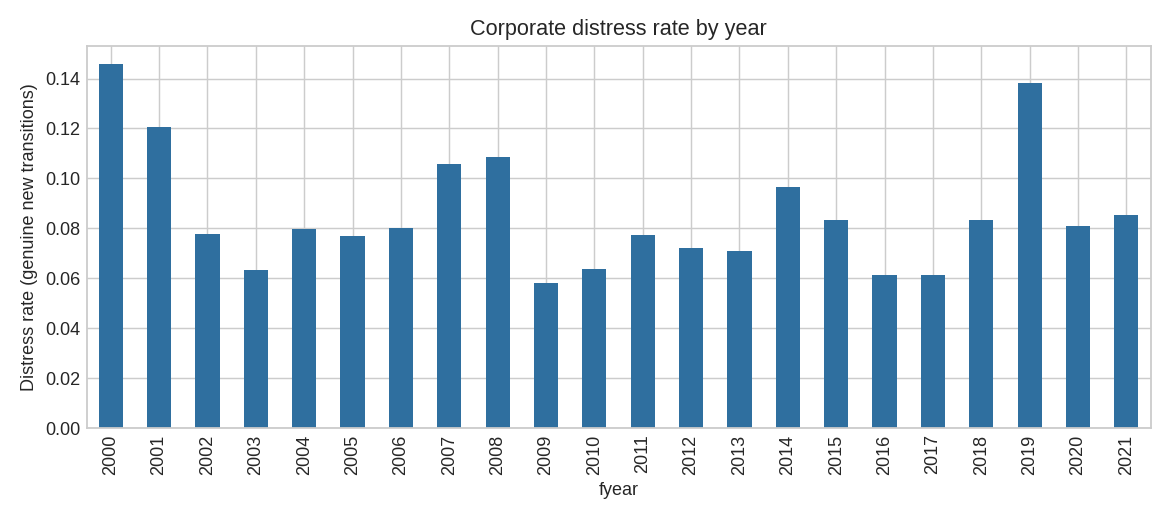

In [11]:
print("Distress rate by year:")
print(df.groupby("fyear")["distress"].mean().round(3))

fig, ax = plt.subplots(figsize=(9,4))
df.groupby("fyear")["distress"].mean().plot(kind="bar", ax=ax, color="#2f6f9f")
ax.set_ylabel("Distress rate (genuine new transitions)")
ax.set_title("Corporate distress rate by year")
plt.tight_layout(); plt.savefig("figs/01_distress_by_year.png", dpi=130); plt.show()

## Cell 12. Correlations Between Ratios and Distress

`size_log` and `retained_ratio` are the strongest negative correlates;
smaller firms with thinner accumulated profit cushions are most likely to
tip into distress. Both leverage measures show only weak raw correlation
here; their relationship with distress turns out to depend heavily on
controlling for other factors, as the causal section below shows.

size_log                  -0.184739
retained_ratio            -0.138049
roa                       -0.053169
long_term_leverage        -0.020319
total_liabilities_ratio   -0.009321
altman_z                  -0.003511
coverage                  -0.001037
current_ratio              0.003415
profit_margin              0.004726
asset_turnover             0.020747
wcap_ratio                 0.066656
dtype: float64


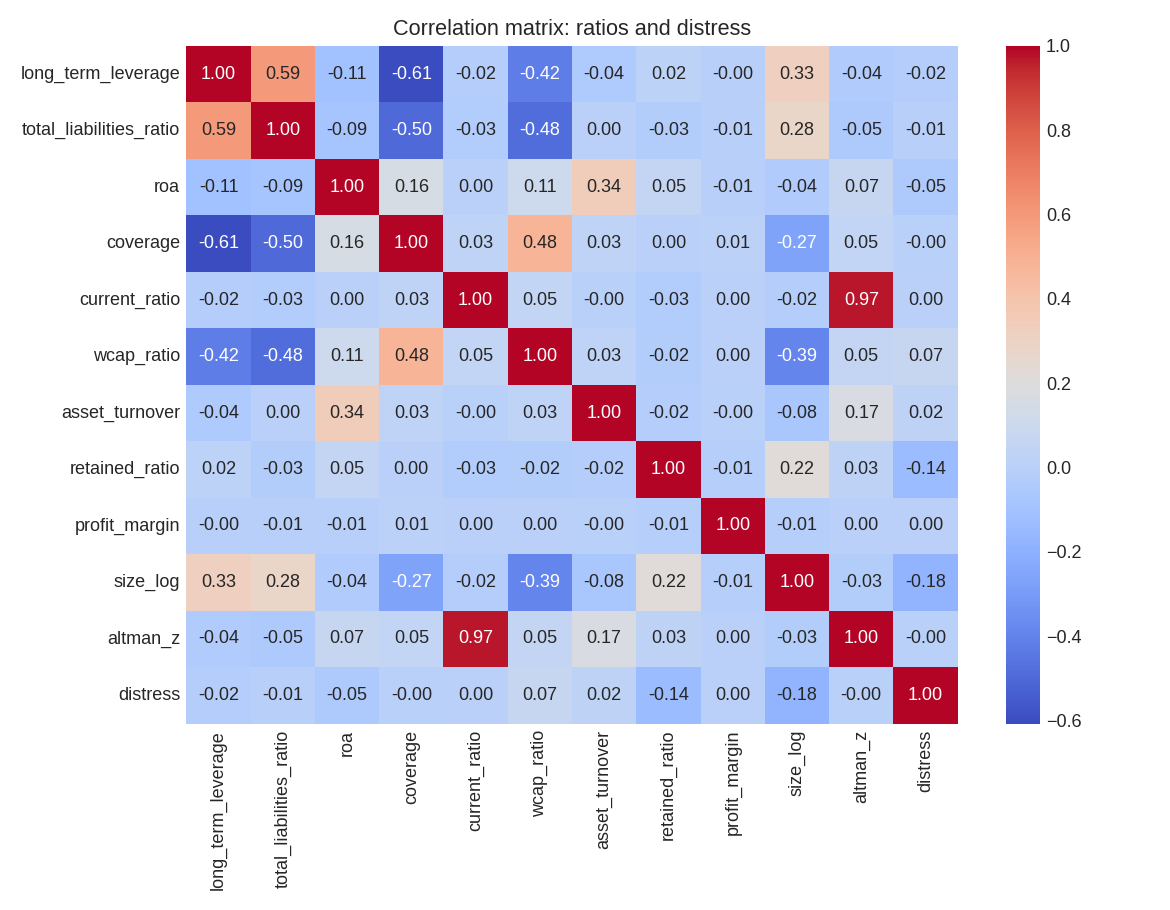

In [12]:
fig, ax = plt.subplots(figsize=(9,7))
sns.heatmap(df[ratio_cols+["distress"]].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlation matrix: ratios and distress")
plt.tight_layout(); plt.savefig("figs/02_corr_heatmap.png", dpi=130); plt.show()
print(df[ratio_cols].corrwith(df["distress"]).sort_values())

## Cell 13. Target Variable Overview

Before moving on to modelling, we look more closely at the target
variable itself: whether a healthy firm transitions into genuine new
distress the following year. The distress rate was already reported by
year in Cell 11; here we check the overall balance of the label and
confirm that the missing value treatment in Cell 7 left no gaps in the
modelling columns.

Missing values in modelling columns (should be zero):
0

Descriptive statistics for the ratio features and the label:
                              mean        std  ...        75%           max
long_term_leverage        0.189745   0.185578  ...   0.307449      0.934853
total_liabilities_ratio   0.495467   0.264011  ...   0.653917     20.586461
roa                       0.052702   0.199704  ...   0.087941     21.789094
coverage                 33.325436  38.365823  ...  60.028650    100.000000
current_ratio             3.002554  56.070500  ...   2.899971  13545.000000
wcap_ratio                0.219747   0.222401  ...   0.359022      0.999926
asset_turnover            1.158338   4.693673  ...   1.397912    982.442128
retained_ratio           -0.019389   1.399144  ...   0.365019      2.661569
profit_margin             0.300712  15.797083  ...   0.236985   3583.800000
size_log                  6.635335   2.234685  ...   8.116090     13.773421
altman_z                  3.098342  33.954737 

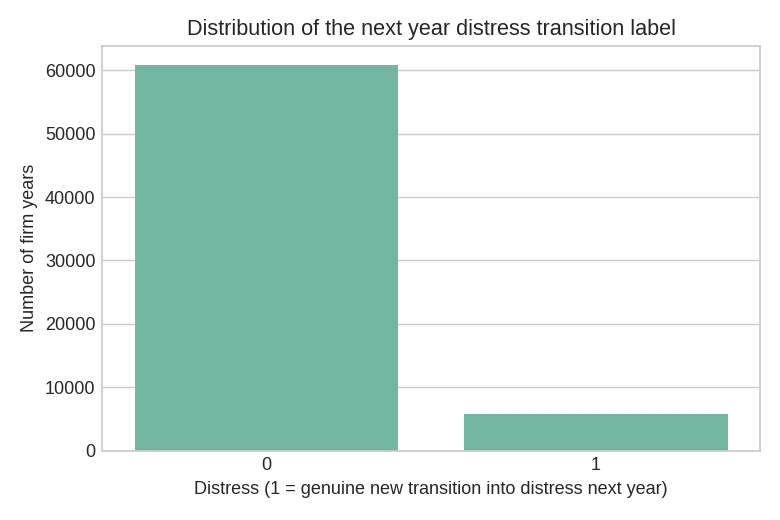

In [13]:
print("Missing values in modelling columns (should be zero):")
print(df[ratio_cols + ["distress"]].isna().sum().sum())

print("\nDescriptive statistics for the ratio features and the label:")
print(df[ratio_cols + ["distress"]].describe().T[["mean","std","min","25%","50%","75%","max"]])

distress_counts = df["distress"].value_counts()
distress_pct = df["distress"].value_counts(normalize=True) * 100
print("\nNext year distress transition label balance:")
print(pd.DataFrame({"count": distress_counts, "percentage": distress_pct.round(2)}))

fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(data=df, x="distress", ax=ax)
ax.set_title("Distribution of the next year distress transition label")
ax.set_xlabel("Distress (1 = genuine new transition into distress next year)")
ax.set_ylabel("Number of firm years")
plt.tight_layout(); plt.savefig("figs/09_distress_balance.png", dpi=130); plt.show()

## Cell 14. Leverage Distribution

`long_term_leverage` is the main explanatory variable in the research
question, so its distribution is worth examining on its own before
comparing it across distress groups. Leverage ratios are bounded below
by zero and have no fixed upper bound, so a right skewed distribution
with a long right tail of highly leveraged firms is the expected shape;
the limited view below clips the axis to the 1st and 99th percentile so
the bulk of the distribution is visible without the extreme tail
flattening the plot.

count    66580.000000
mean         0.189745
std          0.185578
min          0.000000
25%          0.007548
50%          0.152857
75%          0.307449
max          0.934853
Name: long_term_leverage, dtype: float64


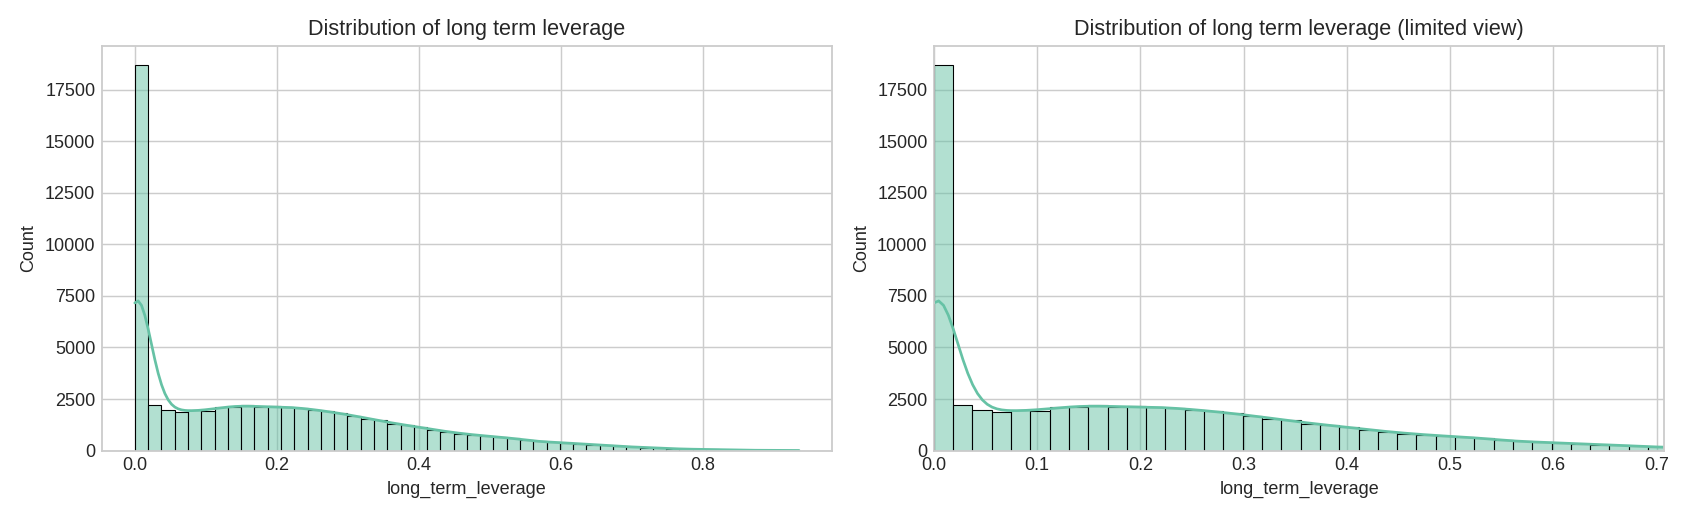

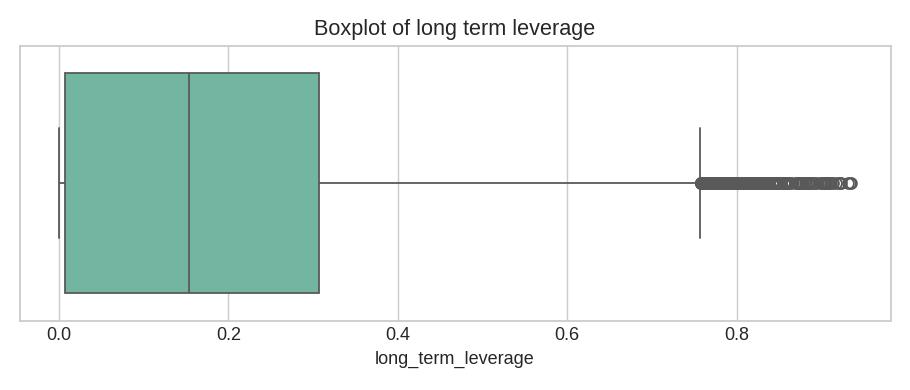

In [14]:
print(df["long_term_leverage"].describe())

fig, axes = plt.subplots(1, 2, figsize=(13,4))
sns.histplot(df["long_term_leverage"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribution of long term leverage")
axes[0].set_xlabel("long_term_leverage")

sns.histplot(df["long_term_leverage"], bins=50, kde=True, ax=axes[1])
axes[1].set_xlim(df["long_term_leverage"].quantile(0.01), df["long_term_leverage"].quantile(0.99))
axes[1].set_title("Distribution of long term leverage (limited view)")
axes[1].set_xlabel("long_term_leverage")
plt.tight_layout(); plt.savefig("figs/10_leverage_distribution.png", dpi=130); plt.show()

fig, ax = plt.subplots(figsize=(7,3))
sns.boxplot(x=df["long_term_leverage"], ax=ax)
ax.set_title("Boxplot of long term leverage")
plt.tight_layout(); plt.savefig("figs/11_leverage_boxplot.png", dpi=130); plt.show()

## Cell 15. Leverage and Financial Distress

We now compare leverage between firms that transition into distress
next year and firms that stay healthy. This comparison is descriptive
only and, on its own, says nothing about causality; the causal inference
section later in this notebook is what actually addresses whether
leverage *causes* distress once confounders are taken into account.

**An openly surprising result worth sitting with rather than glossing
over:** firm years that go on to a genuine new distress transition do
not have higher raw leverage on average; if anything the comparison runs
the other way. Mean `long_term_leverage` is 0.191 for firms that stay
healthy versus 0.178 for firms that transition into distress, and the
gap is sharper at the median (0.158 versus 0.078). Taken at face value,
this would say leverage makes a firm *safer*, which contradicts both
capital structure theory and the causal result found later in this
notebook, where leverage raises distress risk once confounders are
properly accounted for. This is not a contradiction so much as a
demonstration of exactly why a raw, unconditional comparison like this
one is not trustworthy on its own: the relationship between leverage and
distress here is most likely confounded by firm size, profitability,
industry, or how the sample is constructed (only firms large enough and
established enough to be covered by Compustat appear at all, and larger,
more creditworthy firms tend to carry more debt while also being safer
for other reasons). The causal inference section is built specifically
to address this kind of confounding rather than read the raw group
means at face value.

          count      mean    median       std  min       max
distress                                                    
0         60803  0.190907  0.157610  0.182478  0.0  0.933722
1          5777  0.177512  0.078363  0.215157  0.0  0.934853


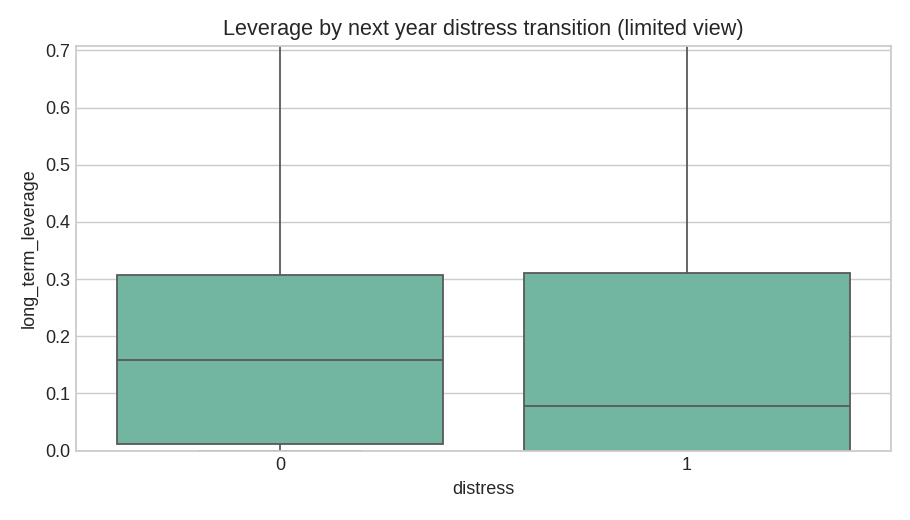

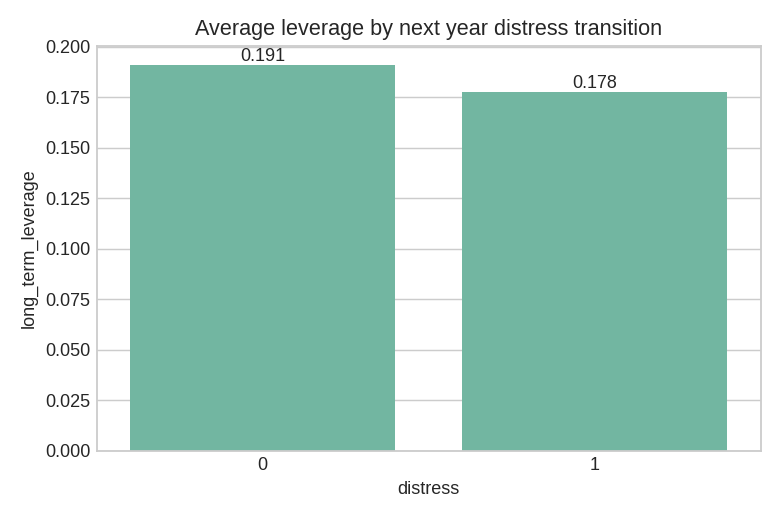

In [15]:
leverage_by_distress = df.groupby("distress")["long_term_leverage"].agg(
    ["count","mean","median","std","min","max"]
)
print(leverage_by_distress)

fig, ax = plt.subplots(figsize=(7,4))
sns.boxplot(data=df, x="distress", y="long_term_leverage", ax=ax)
ax.set_ylim(df["long_term_leverage"].quantile(0.01), df["long_term_leverage"].quantile(0.99))
ax.set_title("Leverage by next year distress transition (limited view)")
plt.tight_layout(); plt.savefig("figs/12_leverage_by_distress_box.png", dpi=130); plt.show()

fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(data=df, x="distress", y="long_term_leverage", errorbar=None, ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")
ax.set_title("Average leverage by next year distress transition")
plt.tight_layout(); plt.savefig("figs/13_leverage_by_distress_bar.png", dpi=130); plt.show()

## Cell 16. Financial Ratios by Distress Status

Beyond leverage, we compare every engineered ratio across firms that do
and do not transition into distress next year. Ranking the ratios by the
raw difference in means is a real problem here: the ratios are on very
different scales (a current ratio that differs by 0.05 is trivial, a
return on assets that differs by 0.05 is enormous), so a raw mean gap
mixes up "the ratio matters a lot" with "the ratio happens to be measured
in big units." The standardized mean difference, also known as Cohen's
d, fixes this by dividing each gap by the pooled standard deviation of
that ratio, putting every ratio on the same scale of "how many standard
deviations apart are the two groups." This is the version of the ranking
that is actually comparable across ratios, and the one this notebook
treats as the expectation to check the Lasso coefficients and Random
Forest importances against later, not the raw mean gap.

In [16]:
def cohens_d(distressed, healthy):
    n1, n2 = len(distressed), len(healthy)
    s1, s2 = distressed.std(ddof=1), healthy.std(ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
    return (distressed.mean() - healthy.mean()) / pooled_std

ratio_summary_by_distress = df.groupby("distress")[ratio_cols].agg(["mean","median","std"])
print(ratio_summary_by_distress)

means_by_distress = df.groupby("distress")[ratio_cols].mean().T
means_by_distress.columns = ["Healthy","Distressed"]
means_by_distress["Raw difference"] = means_by_distress["Distressed"] - means_by_distress["Healthy"]

cohens_d_values = {}
for c in ratio_cols:
    healthy_vals = df.loc[df["distress"] == 0, c]
    distressed_vals = df.loc[df["distress"] == 1, c]
    cohens_d_values[c] = cohens_d(distressed_vals, healthy_vals)
means_by_distress["Standardized difference (Cohen's d)"] = pd.Series(cohens_d_values)

means_by_distress = means_by_distress.sort_values("Standardized difference (Cohen's d)", key=abs, ascending=False)
print("\nRatios ranked by standardized mean difference (Cohen's d), not raw difference:")
print(means_by_distress.round(3))

         long_term_leverage                      ...  altman_z                     
                       mean    median       std  ...      mean    median        std
distress                                         ...                               
0                  0.190907  0.157610  0.182478  ...  3.135093  2.514984  35.090485
1                  0.177512  0.078363  0.215157  ...  2.711537  2.059513  18.096434

[2 rows x 33 columns]

Ratios ranked by standardized mean difference (Cohen's d), not raw difference:
                         Healthy  ...  Standardized difference (Cohen's d)
size_log                   6.763  ...                               -0.668
retained_ratio             0.040  ...                               -0.495
wcap_ratio                 0.215  ...                                0.237
roa                        0.056  ...                               -0.189
asset_turnover             1.128  ...                                0.074
long_term_leverage         

## Cell 17. Distress Rate by Industry

Financial distress is unlikely to be evenly spread across industries,
since different sectors carry different capital structures, margins, and
risk profiles. We compute the distress rate by historical SIC code
(`sich`) and restrict attention to industries with at least 100 firm
years, so that small samples do not produce noisy, unreliable rates at
the top of the ranking. Industry names are taken from the official SEC
Standard Industrial Classification code list, mapped onto the numeric
`sich` codes already in the data, so the chart reads as actual sector
names rather than four digit codes a reader would have to look up.

Industries with at least 100 firm years: 181
                                            industry_name  ...  distress_rate
sich                                                       ...               
2836.0                                Biological Products  ...          24.36
3571.0                               Electronic Computers  ...          22.31
3661.0                  Telephone and Telegraph Apparatus  ...          21.58
7812.0           Motion Picture and Video Tape Production  ...          19.66
3825.0              Instruments for Measuring Electricity  ...          18.16
3576.0                  Computer Communications Equipment  ...          17.23
3669.0                           Communications Equipment  ...          17.02
3663.0  Radio and TV Broadcasting and Communications E...  ...          16.75
3559.0                         Special Industry Machinery  ...          16.39
7371.0                      Computer Programming Services  ...          15.79
2835.0         In V

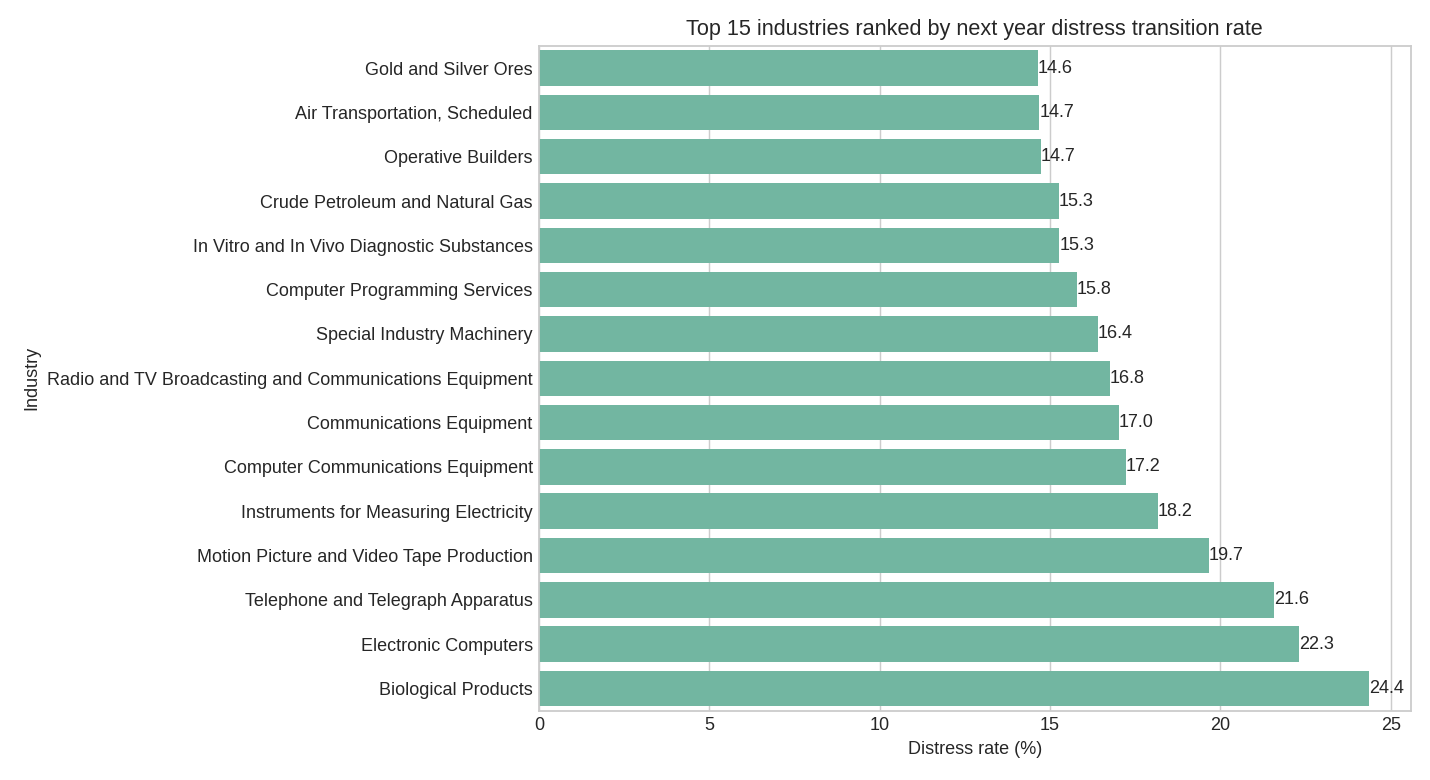

In [17]:
sic_names = {
    1040: "Gold and Silver Ores", 1311: "Crude Petroleum and Natural Gas",
    1531: "Operative Builders", 2835: "In Vitro and In Vivo Diagnostic Substances",
    2836: "Biological Products", 3559: "Special Industry Machinery",
    3571: "Electronic Computers", 3576: "Computer Communications Equipment",
    3661: "Telephone and Telegraph Apparatus",
    3663: "Radio and TV Broadcasting and Communications Equipment",
    3669: "Communications Equipment", 3825: "Instruments for Measuring Electricity",
    4512: "Air Transportation, Scheduled", 7371: "Computer Programming Services",
    7812: "Motion Picture and Video Tape Production",
}

industry_distress = df.groupby("sich").agg(
    observations=("distress","count"),
    distressed_count=("distress","sum"),
    distress_rate=("distress","mean"),
)
industry_distress["distress_rate"] = industry_distress["distress_rate"] * 100
industry_distress = industry_distress[industry_distress["observations"] >= 100]
industry_distress = industry_distress.sort_values("distress_rate", ascending=False)

print(f"Industries with at least 100 firm years: {len(industry_distress):,}")
top15 = industry_distress.head(15).copy()
top15["industry_name"] = [sic_names.get(int(s), str(int(s))) for s in top15.index]
print(top15[["industry_name","observations","distressed_count","distress_rate"]].round(2))

top15_sorted = top15.sort_values("distress_rate", ascending=True).reset_index()
fig, ax = plt.subplots(figsize=(11,6))
sns.barplot(data=top15_sorted, x="distress_rate", y="industry_name", orient="h", ax=ax)
ax.set_title("Top 15 industries ranked by next year distress transition rate")
ax.set_xlabel("Distress rate (%)")
ax.set_ylabel("Industry")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")
plt.tight_layout(); plt.savefig("figs/14_industry_distress.png", dpi=130); plt.show()

## Cell 18. Observations by Year

The distress rate over time in Cell 11 is reported as a rate rather
than a raw count specifically so that it is not distorted by years with
more or fewer observations. This cell makes that sample size directly
visible, so a reader can judge whether any year with an unusually high
or low distress rate also happens to be a year with very few
observations, which would make that particular rate less reliable.

fyear
2000    3897
2001    3513
2002    3448
2003    3535
2004    3636
2005    3503
2006    3340
2007    3305
2008    3183
2009    3007
2010    3098
2011    3059
2012    3007
2013    2952
2014    2797
2015    2594
2016    2482
2017    2519
2018    2498
2019    2450
2020    2296
2021    2461
Name: count, dtype: int64


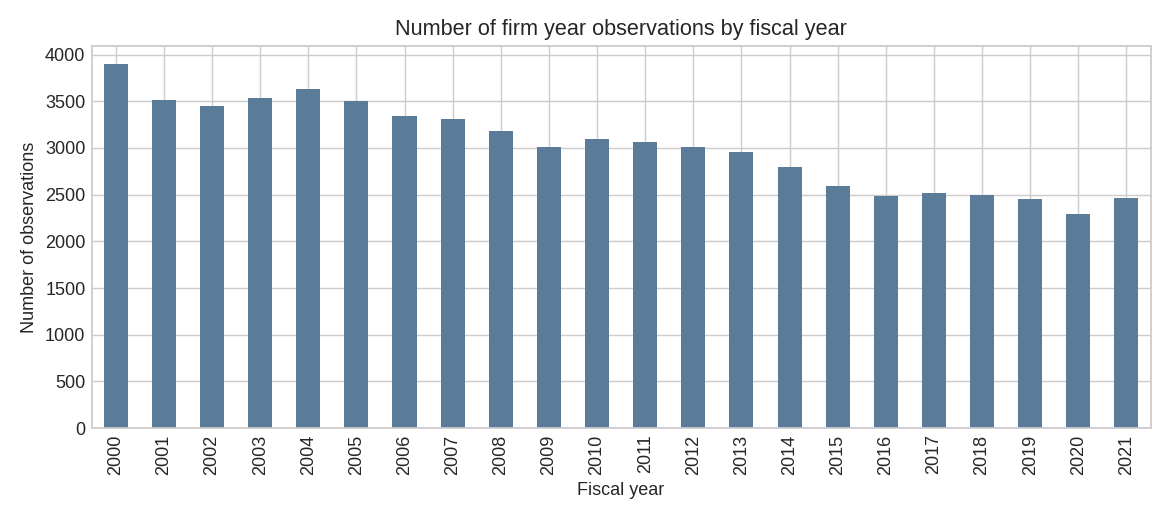

In [18]:
observations_by_year = df["fyear"].value_counts().sort_index()
print(observations_by_year)

fig, ax = plt.subplots(figsize=(9,4))
observations_by_year.plot(kind="bar", ax=ax, color="#5b7c99")
ax.set_title("Number of firm year observations by fiscal year")
ax.set_xlabel("Fiscal year")
ax.set_ylabel("Number of observations")
plt.tight_layout(); plt.savefig("figs/15_observations_by_year.png", dpi=130); plt.show()

## Cell 19. Exploratory Analysis Summary

Pulling the exploratory analysis together before moving on to causal
inference and modelling:

- The next year distress transition label is balanced enough to model
  directly (no extreme rarity once persistence is excluded, as already
  quantified in Cell 9 and Cell 11), but is far from a coin flip, so the
  choice of `class_weight="balanced"` in the supervised models later is
  justified rather than a default left unexamined.
- Leverage on its own, compared raw across firms that do and do not
  transition into distress, does not separate the two groups in the
  expected direction; if anything firms that transition into distress
  carry slightly lower average leverage. This openly surprising pattern,
  discussed directly in Cell 15, is exactly what motivates running a
  proper causal adjustment instead of reading the raw group means at
  face value.
- The standardized ratio gap table in Cell 16 (Cohen's d, not raw
  differences) shows which financial ratios separate the two groups most
  sharply once every ratio is put on the same scale, giving a concrete
  set of expectations to check the Lasso coefficients and Random Forest
  feature importances against later.
- Next year distress transitions are not evenly distributed across
  industries or across years, which is the empirical justification for
  including `sich` as a confounder in the causal inference section
  rather than leaving industry out of the adjustment set entirely.

## 4. Planned Methods

Methods applied, one from each of the three required blocks:

### 4a. Causal Inference
- [x] Backdoor adjustment
- [x] Causal graph / DAG (DoWhy)
- [ ] Instrumental variable
- [ ] Propensity score stratification
- [ ] Other: ___

*Justification:* Leverage is a classic case of confounded causal inference in finance: firm size and profitability both affect a firm's access to long term debt *and* its distress risk independently. We use backdoor adjustment twice: first informally (a naive bivariate logistic model against one adjusted for `size_log`, `roa`, and `profit_margin`), then formally with an explicit DoWhy causal graph and a seven variable adjustment set, together with firm fixed effects, a placebo treatment refuter, and a sensitivity analysis to check the result is not an artifact of the adjustment procedure or of an unmeasured confounder.

### 4b. Supervised Learning
- [x] Linear / Ridge / Lasso regression
- [x] Logistic regression
- [ ] K Nearest Neighbors
- [x] Support Vector Machine
- [x] Decision Tree / Random Forest
- [x] Neural network (regression or classification)
- [ ] Other: ___

*Justification:* Distress prediction is a binary classification problem with a rare positive class (8.7% base rate). We compare a linear baseline (logistic regression, with Lasso for feature selection), a nonlinear kernel method (SVM), and two nonparametric or deep methods (Random Forest, a small MLP) to see whether nonlinear interactions between ratios add predictive power over a linear baseline.

### 4c. Unsupervised Learning / Generative Models
- [x] KMeans clustering
- [ ] Hierarchical clustering
- [ ] Variational autoencoder
- [ ] GAN
- [x] Other: PCA (dimensionality reduction, used to visualize the KMeans clusters in 2D)

*Justification:* KMeans lets us segment firms into financial risk profiles using the ratios alone, with no label involved, and check whether the resulting clusters' distress rates differ in ways consistent with (or in tension with) the causal result on leverage.


## 5. Evaluation Strategy

- **Supervised models:** AUC (primary metric, robust to the 8.7% class imbalance), accuracy, and F1, all computed on a test period the models never saw during training or winsorization (`fyear` 2017 and later, a time based split rather than a random one, so training never includes observations from after the test period). ROC and precision recall curves are reported together, since the precision recall view is the more honest picture once the positive class is rare. Every model is also compared against two stated baselines, the Altman Z score and a predict majority class rule, in the same table as the trained models.
- **Causal claims:** validated five ways. First, by comparing a naive (unadjusted) coefficient for leverage against a coefficient adjusted for size and profitability; a sign flip between the two is the diagnostic for confounding. Second, by building an explicit DoWhy causal graph over a seven variable adjustment set and computing the Average Treatment Effect through backdoor adjustment, with standard errors clustered by firm throughout since this is panel data. Third, by a firm fixed effects robustness check that absorbs every unobserved, time invariant firm characteristic at once, not only the named confounders. Fourth, by a placebo treatment refuter, which checks that the estimated effect collapses toward zero when leverage is randomly shuffled. Fifth, by a sensitivity analysis that finds how strong a hidden, unmeasured confounder would have to be to overturn the result, rather than assuming none exists.
- **Unsupervised output:** evaluated qualitatively by comparing each KMeans cluster's mean ratio profile and Altman Z score against its empirical distress rate, checking whether the segmentation is internally consistent with both the raw correlations and the causal result.
- **Baseline / benchmark:** the classical Altman Z score (already engineered as a feature, `altman_z`) is used as the benchmark; outperforming it is the bar for the supervised models. We also benchmark all models against a "predict majority class" baseline implied by the 8.7% base rate.


## 6. Work Plan

| Step | Owner | Description |
|------|-------|-------------|
| 1 | Usama Saleem | Data collection (WRDS/Compustat pull) & cleaning |
| 2 | Ekin Yuecesan | EDA (target variable, leverage, ratio comparisons, industry and time patterns) |
| 3 | Usama Saleem | Causal inference block (backdoor adjustment on leverage) |
| 4 | Ekin Yuecesan | Supervised learning block (Lasso, Logistic, SVM, Random Forest, Neural Network) |
| 5 | Zi Zhang | Unsupervised block (PCA + KMeans segmentation) |
| 6 | All | Synthesis and write up |


---
## 7. Results

### 7a. Causal Inference

## Causal Inference: Does Leverage *Cause* Distress?

**A genuinely interesting result here: the sign flips.**

- **Naive** (leverage alone): coefficient is **negative** (-0.400); taken
  at face value, this would say firms with more leverage are *less* likely to
  become distressed, which contradicts capital structure theory.
- **Adjusted** (controlling for size, profitability): coefficient becomes
  **positive** (+0.829); once you account for the fact that larger,
  firms that are more profitable tend to carry *more* long term debt (they have
  better access to credit markets) while also being inherently safer, the
  true relationship emerges again: leverage does raise distress risk.

This is a textbook confounding example: firm size and profitability are
confounders that mask leverage's true effect in the raw, unadjusted data.

**Standard errors are clustered by firm (`gvkey`) throughout this
section.** This is panel data: the same firm appears in many years, and
rows from the same firm are not independent observations of each other.
Treating all 66,580 rows as independent, the way a plain logistic fit
does by default, would overstate how confident the p values look. Both
models below cluster standard errors by `gvkey`, the standard fix for
panel data; it does not change the coefficients themselves, only how
much weight their precision deserves.

In [19]:
df_causal = df.copy()
X_naive = sm.add_constant(df_causal["long_term_leverage"])
naive_model = sm.Logit(df_causal["distress"], X_naive).fit(
    disp=0, cov_type="cluster", cov_kwds={"groups": df_causal["gvkey"]}
)

naive_adjusted_confounders = ["long_term_leverage", "size_log", "roa", "profit_margin"]
X_adj = sm.add_constant(df_causal[naive_adjusted_confounders])
adj_model = sm.Logit(df_causal["distress"], X_adj).fit(
    disp=0, cov_type="cluster", cov_kwds={"groups": df_causal["gvkey"]}
)

print(f"Leverage coef (naive):    {naive_model.params['long_term_leverage']:.3f}  (p={naive_model.pvalues['long_term_leverage']:.4f})")
print(f"Leverage coef (adjusted): {adj_model.params['long_term_leverage']:.3f}  (p={adj_model.pvalues['long_term_leverage']:.4f})")
print(f"Odds ratio (adjusted) for +0.1 leverage: {np.exp(adj_model.params['long_term_leverage']*0.1):.3f}")

Leverage coef (naive):    -0.400  (p=0.0001)
Leverage coef (adjusted): 0.829  (p=0.0000)
Odds ratio (adjusted) for +0.1 leverage: 1.086


## Causal Graph and Backdoor Adjustment (DoWhy)

The naive versus adjusted comparison above adjusts for only three
confounders chosen by hand. Here we make the assumed causal structure
explicit by drawing a directed graph and letting DoWhy derive the
adjustment set from it, rather than picking confounders informally.

**On the choice of confounders, and two variables deliberately left
out:** `coverage` (`ebitda / xint`) and `total_liabilities_ratio`
(`lt / at`) are not included here, even though they are correlated with
distress, because both are too entangled with the treatment itself to
serve as confounders. `xint` (interest expense, the denominator of
coverage) is mechanically driven by how much debt a firm carries, so
treating coverage as a cause of leverage gets the direction of that
relationship backwards for at least part of it. `total_liabilities_ratio`
overlaps with leverage by construction, since `dltt` (long term debt,
the numerator of `long_term_leverage`) is literally a component of `lt`
(total liabilities, the numerator of `total_liabilities_ratio`); the two
are not independent variables. Controlling for a variable that is partly
mechanically downstream of, or definitionally tangled with, the
treatment is a known way to bias a causal estimate rather than clean it
up, so neither is treated as a confounder.

**Confounder set:** seven variables (`roa`, `profit_margin`,
`size_log`, `current_ratio`, `asset_turnover`, `retained_ratio`, and
industry `sich`) are treated as common causes of both leverage and
distress. These are chosen on economic reasoning about what plausibly
shapes both a firm's financing choice and its risk, decided before
looking at any results; two of them turn out not to be statistically
significant in the regression below, and they stay in the model anyway,
since picking confounders by which ones turn out significant afterward
is itself a way to bias the result, not a way to improve it.

`sich` is cast to a string before it enters the model so DoWhy treats
each industry as its own category (a set of fixed effects), rather than
treating the numeric SIC code as if it were an ordered quantity, which
it is not. `gvkey` is also kept in the sample, unused by the graph
itself, so the regressions below can cluster standard errors by firm.

In [20]:
from dowhy import CausalModel
import networkx as nx

confounders = ["roa", "profit_margin", "size_log", "current_ratio",
               "asset_turnover", "retained_ratio", "sich"]

causal_df = df[["long_term_leverage", "distress", "gvkey"] + confounders].copy()
n_before = len(causal_df)
causal_df = causal_df.dropna()
print(f"Rows dropped for missing values in the causal sample: {n_before - len(causal_df):,}")
causal_df["sich"] = causal_df["sich"].astype(str)

graph_edges = []
for c in confounders:
    graph_edges.append(f"{c} -> long_term_leverage;")
    graph_edges.append(f"{c} -> distress;")
graph_edges.append("long_term_leverage -> distress;")
causal_graph = "digraph {\n" + "\n".join(graph_edges) + "\n}"

model = CausalModel(
    data=causal_df,
    treatment="long_term_leverage",
    outcome="distress",
    graph=causal_graph,
)

identified_estimand = model.identify_effect()
print("========== Identified Estimand ==========")
print(identified_estimand)

Rows dropped for missing values in the causal sample: 0
========== Identified Estimand ==========
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
          d                                                                    ↪
─────────────────────(E[distress|current_ratio,sich,size_log,roa,asset_turnove ↪
d[long_term_leverage]                                                          ↪

↪                                 
↪ r,retained_ratio,profit_margin])
↪                                 
Estimand assumption 1, Unconfoundedness: If U→{long_term_leverage} and U→distress then P(distress|long_term_leverage,current_ratio,sich,size_log,roa,asset_turnover,retained_ratio,profit_margin,U) = P(distress|long_term_leverage,current_ratio,sich,size_log,roa,asset_turnover,retained_ratio,profit_margin)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### E

## Drawing the Causal Graph

A plain visual of the same graph used above, with leverage in orange and
distress in red, makes the assumed structure easy to check at a glance:
every confounder points at both leverage and distress, and the single
edge of direct interest runs from leverage to distress.

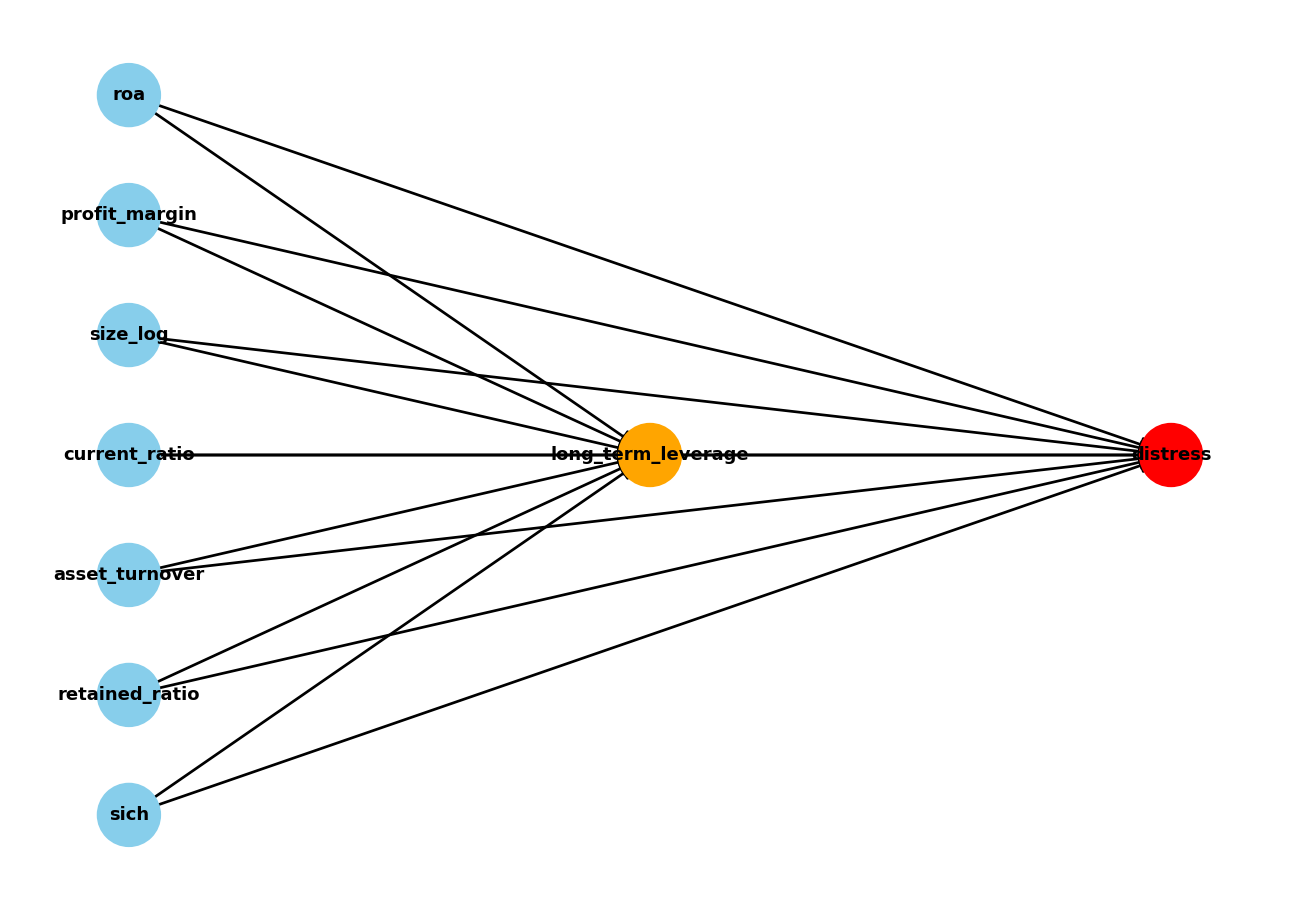

In [21]:
pos = {
    "roa": (-1, 3), "profit_margin": (-1, 2), "size_log": (-1, 1),
    "current_ratio": (-1, 0), "asset_turnover": (-1, -1),
    "retained_ratio": (-1, -2), "sich": (-1, -3),
    "long_term_leverage": (2, 0),
    "distress": (5, 0),
}

G = nx.DiGraph()
G.add_edges_from([(c, "long_term_leverage") for c in confounders] +
                  [(c, "distress") for c in confounders] +
                  [("long_term_leverage", "distress")])

node_colors = []
for node in G.nodes():
    if node == "long_term_leverage":
        node_colors.append("orange")
    elif node == "distress":
        node_colors.append("red")
    else:
        node_colors.append("skyblue")

plt.figure(figsize=(10, 7))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1200)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")
nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=18, width=1.5)
plt.axis("off")
plt.tight_layout()
plt.savefig("figs/08_causal_graph.png", dpi=130)
plt.show()

## Estimating the Average Treatment Effect

DoWhy translates the graph above into a regression formula automatically
(the printed estimand lists every confounder it decided to adjust for),
then `backdoor.linear_regression` fits that regression and reports the
Average Treatment Effect (ATE): the average change in the probability of
distress associated with a one unit increase in `long_term_leverage`,
holding the seven confounders fixed. Because `distress` is binary, this
is a linear probability model rather than a logistic one, so the result
is read directly as a probability point change rather than a log odds
coefficient. **This is a different number on a different scale from the
adjusted logistic coefficient above; the two should be read for
direction and significance, not compared as if they were the same
quantity.**

In [22]:
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression",
)

print("========== Backdoor Adjustment Result ==========")
print(estimate)
print("\nEstimated Average Treatment Effect (ATE):", estimate.value)

========== Backdoor Adjustment Result ==========
*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
          d                                                                    ↪
─────────────────────(E[distress|current_ratio,sich,size_log,roa,asset_turnove ↪
d[long_term_leverage]                                                          ↪

↪                                 
↪ r,retained_ratio,profit_margin])
↪                                 
Estimand assumption 1, Unconfoundedness: If U→{long_term_leverage} and U→distress then P(distress|long_term_leverage,current_ratio,sich,size_log,roa,asset_turnover,retained_ratio,profit_margin,U) = P(distress|long_term_leverage,current_ratio,sich,size_log,roa,asset_turnover,retained_ratio,profit_margin)

## Realized estimand
b: distress~long_term_leverage+current_ratio+sich+size_log+roa+asset_turnover+retained_ratio+profit_margin
Target unit

## Full Coefficient Matrix, Clustered Standard Errors, and Diagnostics

This cell refits the backdoor regression directly with `statsmodels`
rather than reading the single ATE coefficient off DoWhy's internal
estimator, for two reasons that both point to the same fix.

**Clustered standard errors:** the same panel data issue from the naive
versus adjusted comparison applies here too, so standard errors are
clustered by `gvkey` in this refit.

**Heteroskedasticity:** plain OLS standard errors assume constant
variance in the residuals, which a binary outcome essentially guarantees
is false, since the variance of a 0/1 outcome mechanically depends on
its mean. Cluster robust standard errors are also robust to this kind of
heteroskedasticity, so the same fix addresses both issues at once.

**A small honest discrepancy worth naming:** this refit's
`long_term_leverage` coefficient is close to, but not exactly equal to,
the DoWhy ATE above. With a sich dummy matrix this wide sitting in a
fairly small confounder set, the two libraries' solvers land on very
slightly different numbers; the difference is in the fourth decimal
place and does not change any conclusion, but it would be dishonest to
claim an exact match that does not actually hold.

**Diagnostic 1, does the linear probability model stay in range:** a
linear model fit to a 0/1 outcome can predict a probability below 0 or
above 1, which is meaningless; the fitted values are checked directly
rather than assumed to behave.

**Diagnostic 2, multicollinearity:** the variance inflation factor (VIF)
for every continuous variable in the model checks whether the
confounders are dangerously correlated with each other or with leverage,
which would inflate standard errors and make individual coefficients
unstable. VIF above 5 to 10 is the usual concern threshold.

**Diagnostic 3, economic magnitude:** statistical significance is not
the same question as whether the effect is large enough to matter
practically; the ATE is also expressed as a percentage of the base
distress rate, so the size of the effect is on the table, not just its
p value.

In [23]:
backdoor_formula = (
    "distress ~ long_term_leverage + roa + size_log + current_ratio + "
    "profit_margin + retained_ratio + C(sich)"
)
backdoor_ols = smf.ols(backdoor_formula, data=causal_df).fit(
    cov_type="cluster", cov_kwds={"groups": causal_df["gvkey"]}
)

coef_matrix = pd.DataFrame({
    "coef": backdoor_ols.params,
    "std_err": backdoor_ols.bse,
    "p_value": backdoor_ols.pvalues,
})

main_vars = ["Intercept", "long_term_leverage", "roa", "size_log", "current_ratio",
             "profit_margin", "retained_ratio"]
print("Coefficient matrix for the treatment and the non industry confounders (clustered SEs):")
print(coef_matrix.loc[main_vars].round(4))

sich_coefs = coef_matrix[coef_matrix.index.str.startswith("C(sich)")]
print(f"\nIndustry fixed effects included: {len(sich_coefs)}")
print(f"long_term_leverage coefficient here: {backdoor_ols.params['long_term_leverage']:.4f}")
print(f"DoWhy ATE for comparison: {estimate.value:.4f}")

fitted = backdoor_ols.fittedvalues
print(f"\nFitted probability range: {fitted.min():.3f} to {fitted.max():.3f}")
print(f"Share of fitted values outside [0,1]: {((fitted < 0) | (fitted > 1)).mean():.3f}")

base_rate = causal_df["distress"].mean()
print(f"\nATE as a share of the base distress rate ({base_rate:.3f}): "
      f"{estimate.value/base_rate:.1%} relative increase for a full 0 to 1 swing in leverage")

vif_vars = ["long_term_leverage", "roa", "profit_margin", "size_log",
            "current_ratio", "asset_turnover", "retained_ratio"]
vif_X = sm.add_constant(causal_df[vif_vars])
vif_result = pd.Series(
    [variance_inflation_factor(vif_X.values, i) for i in range(1, vif_X.shape[1])],
    index=vif_vars
)
print("\nVariance inflation factors (no concern below 5):")
print(vif_result.round(2))

Coefficient matrix for the treatment and the non industry confounders (clustered SEs):
                      coef  std_err  p_value
Intercept           0.2720   0.0284   0.0000
long_term_leverage  0.0914   0.0089   0.0000
roa                -0.0733   0.0198   0.0002
size_log           -0.0251   0.0009   0.0000
current_ratio      -0.0000   0.0000   0.4289
profit_margin      -0.0000   0.0001   0.9760
retained_ratio     -0.0164   0.0036   0.0000

Industry fixed effects included: 389
long_term_leverage coefficient here: 0.0914
DoWhy ATE for comparison: 0.0906

Fitted probability range: -1.535 to 1.994
Share of fitted values outside [0,1]: 0.096

ATE as a share of the base distress rate (0.087): 104.4% relative increase for a full 0 to 1 swing in leverage

Variance inflation factors (no concern below 5):
long_term_leverage    1.13
roa                   1.15
profit_margin         1.00
size_log              1.18
current_ratio         1.00
asset_turnover        1.14
retained_ratio        1.06


## Robustness Check: Firm Fixed Effects (Within Estimator)

The backdoor adjustment above only controls for the seven confounders
we explicitly named. It cannot account for anything about a firm that we
did not measure, such as management quality or brand strength, unless
that unmeasured trait happens to be captured by one of the seven
variables. Firm fixed effects address this differently: rather than
naming every possible confounder, they absorb every characteristic of a
firm that does not change over time, observed or not, by comparing each
firm only to its own history.

Fitting this as a literal regression with one dummy per firm is not
practical here (8,508 firms, dramatically more columns than the 389
industry dummies already in the model above). The within estimator gets
the identical answer without creating those columns: subtract each
firm's own mean from every variable, then run the regression on what is
left over. Firms that appear only once in the panel have no within firm
variation to contribute and drop out of this estimate entirely, which is
expected, not an error.

In [24]:
continuous_vars = ["long_term_leverage", "distress", "roa", "profit_margin",
                    "size_log", "current_ratio", "asset_turnover", "retained_ratio"]

firm_counts = causal_df["gvkey"].value_counts()
n_singleton = (firm_counts == 1).sum()
print(f"Firms appearing only once (no within firm variation, contribute nothing): {n_singleton:,} of {causal_df['gvkey'].nunique():,}")

demeaned = causal_df[continuous_vars].copy()
firm_means = demeaned.groupby(causal_df["gvkey"]).transform("mean")
demeaned = demeaned - firm_means

X_within = sm.add_constant(demeaned[["long_term_leverage", "roa", "profit_margin",
                                       "size_log", "current_ratio", "asset_turnover", "retained_ratio"]])
within_model = sm.OLS(demeaned["distress"], X_within).fit(
    cov_type="cluster", cov_kwds={"groups": causal_df["gvkey"]}
)
print(f"\nWithin estimator leverage coefficient: {within_model.params['long_term_leverage']:.4f}  (p={within_model.pvalues['long_term_leverage']:.4f})")
print(f"Backdoor adjustment ATE for comparison: {estimate.value:.4f}")
print("Both positive and significant: the result survives controlling for every unobserved,")
print("time invariant firm characteristic at once, not only the seven confounders named above.")

Firms appearing only once (no within firm variation, contribute nothing): 1,499 of 8,508

Within estimator leverage coefficient: 0.0747  (p=0.0000)
Backdoor adjustment ATE for comparison: 0.0906
Both positive and significant: the result survives controlling for every unobserved,
time invariant firm characteristic at once, not only the seven confounders named above.


## Refutation: Placebo Treatment

A causal estimate is only convincing if it disappears when it should.
The placebo treatment refuter randomly shuffles `long_term_leverage`
across firms, breaking any real relationship between leverage and
distress, then reruns the same backdoor adjustment on the shuffled data.
If the estimated effect collapses toward zero under shuffling while the
original estimate does not, that is evidence the original result reflects
a genuine pattern in the data rather than an artifact of the adjustment
procedure itself.

`num_simulations` is set to 20 rather than left at its default of 100.
With `sich` expanding into well over a hundred industry dummy columns,
each simulation refits a regression of that width, and 100 refits take
several minutes; 20 is enough to see whether the placebo effect collapses
while keeping the cell runnable in a normal session. One honest
limitation: DoWhy's internal refits for this refuter do not cluster
standard errors the way the cells above do, so this check speaks to
whether the size of the *point estimate* collapses, not to the precision
of its standard error.

In [25]:
refute_placebo = model.refute_estimate(
    identified_estimand, estimate,
    method_name="placebo_treatment_refuter",
    placebo_type="permute",
    num_simulations=20,
)
print(refute_placebo)

Refute: Use a Placebo Treatment
Estimated effect:0.09056713734429933
New effect:-0.00027757419834014975
p value:0.4723582631156852



## Refutation: Sensitivity to an Unobserved Confounder

The placebo test above checks one specific failure mode. It says nothing
about the deeper, unavoidable assumption behind backdoor adjustment:
that there is no confounder left out of the graph entirely. That
assumption cannot be tested directly, since by definition we have no
data on what we did not measure, but it can be probed by simulation: add
a hypothetical unobserved variable with a chosen strength of association
to both leverage and distress, and see how strong it would have to be
before the result flips sign.

For context on what a given strength means in practice, `size_log` on
its own explains about 3.4% of the variation in distress (an R squared
of 0.034), the strongest of the seven named confounders individually.
The two effect strengths below are chosen to bracket that benchmark.
One honest note: this particular refuter draws its hypothetical
confounder randomly each time it runs, and does not expose a fixed seed
the way the rest of this notebook controls for elsewhere, so the exact
number at the boundary can shift slightly between runs; the conclusion
it supports (a confounder around this strength is enough to push the
effect close to zero, or past it) is the stable part, not the fourth
decimal place.

In [26]:
size_log_r2 = sm.OLS(causal_df["distress"], sm.add_constant(causal_df["size_log"])).fit().rsquared
print(f"For context, size_log alone explains an R squared of {size_log_r2:.3f} of distress.\n")

for strength in [0.02, 0.045]:
    refute_unobserved = model.refute_estimate(
        identified_estimand, estimate,
        method_name="add_unobserved_common_cause",
        confounders_effect_on_treatment="linear",
        confounders_effect_on_outcome="linear",
        effect_strength_on_treatment=strength,
        effect_strength_on_outcome=strength,
    )
    print(f"--- Hypothetical confounder strength {strength} ---")
    print(refute_unobserved)
    print()

For context, size_log alone explains an R squared of 0.034 of distress.

--- Hypothetical confounder strength 0.02 ---
Refute: Add an Unobserved Common Cause
Estimated effect:0.09056713734429933
New effect:0.07331149176397328


--- Hypothetical confounder strength 0.045 ---
Refute: Add an Unobserved Common Cause
Estimated effect:0.09056713734429933
New effect:0.0035276727369165928




### 7b. Supervised Learning

## Train, Validation, and Test Split (Time Based, No Leakage)

Firm years are split by fiscal year rather than at random. A random
split would let, for example, a 2020 observation train a model that is
then asked to predict a 2010 outcome, which is backwards from how the
model would ever actually be used: in practice you only ever have the
past available to predict the future. The financial distress forecasting
literature treats a chronological split as standard practice rather than
an optional refinement; studies in this area generally train on
observations before a cutoff date and evaluate on observations after it,
precisely so that performance reflects genuine forecasting rather than
information that would not have been available at the time.

Three periods, not two:

- **Train** (`fyear` 2000 to 2014): every model below is fit only on
  this period.
- **Validation** (`fyear` 2015 to 2016): held out from fitting entirely.
  Used later in this section to choose where Random Forest's permutation
  importance is measured and to give the Neural Network a consistent,
  time based validation set instead of an arbitrary random split of its
  own training data.
- **Test** (`fyear` 2017 to 2021): touched only once, to report final
  performance.

Winsorization bounds are computed on the training period only and the
same bounds are then applied to validation and test, for the same no
leakage reason.

In [27]:
feature_cols = ratio_cols

train_mask = df["fyear"] <= 2014
val_mask = (df["fyear"] >= 2015) & (df["fyear"] <= 2016)
test_mask = df["fyear"] >= 2017

X_train = df.loc[train_mask, feature_cols].copy()
X_val   = df.loc[val_mask, feature_cols].copy()
X_test  = df.loc[test_mask, feature_cols].copy()
y_train = df.loc[train_mask, "distress"].values
y_val   = df.loc[val_mask, "distress"].values
y_test  = df.loc[test_mask, "distress"].values

for name, X_split, y_split, fyear_desc in [
    ("Train", X_train, y_train, "fyear <= 2014"),
    ("Validation", X_val, y_val, "fyear 2015 to 2016"),
    ("Test", X_test, y_test, "fyear >= 2017"),
]:
    print(f"{name}: {X_split.shape}, distress observations: {y_split.sum():,}, "
          f"distress rate: {y_split.mean():.4f}  ({fyear_desc})")

winsor_bounds = {}
for c in feature_cols:
    lo, hi = X_train[c].quantile(0.01), X_train[c].quantile(0.99)
    winsor_bounds[c] = (lo, hi)
    X_train[c] = X_train[c].clip(lo, hi)
    X_val[c]   = X_val[c].clip(lo, hi)
    X_test[c]  = X_test[c].clip(lo, hi)   # SAME bounds as training; no leakage
print("\nWinsorization bounds computed on TRAINING data only, applied to validation and test.")

scaler = StandardScaler().fit(X_train.values)
X_train_s = scaler.transform(X_train.values)
X_val_s   = scaler.transform(X_val.values)
X_test_s  = scaler.transform(X_test.values)

Train: (49280, 11), distress observations: 4,312, distress rate: 0.0875  (fyear <= 2014)
Validation: (5076, 11), distress observations: 368, distress rate: 0.0725  (fyear 2015 to 2016)
Test: (12224, 11), distress observations: 1,097, distress rate: 0.0897  (fyear >= 2017)

Winsorization bounds computed on TRAINING data only, applied to validation and test.


## Lasso for Coefficient Shrinkage and Ranking

Five fold cross validation over 30 penalty strengths, on the training
period only. We are deliberately not calling this "feature selection"
below: with only 11 ratios, several of them correlated, the cross
validated penalty strength is not aggressive enough to drive any
coefficient to an exact zero, so nothing actually gets dropped. What
this cell still gives us is a ranking, by shrinkage, of which ratios the
data supports most strongly, which is a real and useful result on its
own; it is just not the same claim as selection. The printed coefficients
below are read directly off this run rather than restated from memory,
since they will shift slightly now that the split is time based instead
of random.

Lasso coefficients (best C=0.1172):
size_log                  -0.653968
asset_turnover            -0.411566
total_liabilities_ratio    0.370572
retained_ratio            -0.327384
roa                       -0.301612
profit_margin             -0.289616
altman_z                   0.252723
wcap_ratio                 0.163185
coverage                  -0.080485
current_ratio              0.038142
long_term_leverage        -0.010877
dtype: float64

Exact zero coefficients: 0 of 11


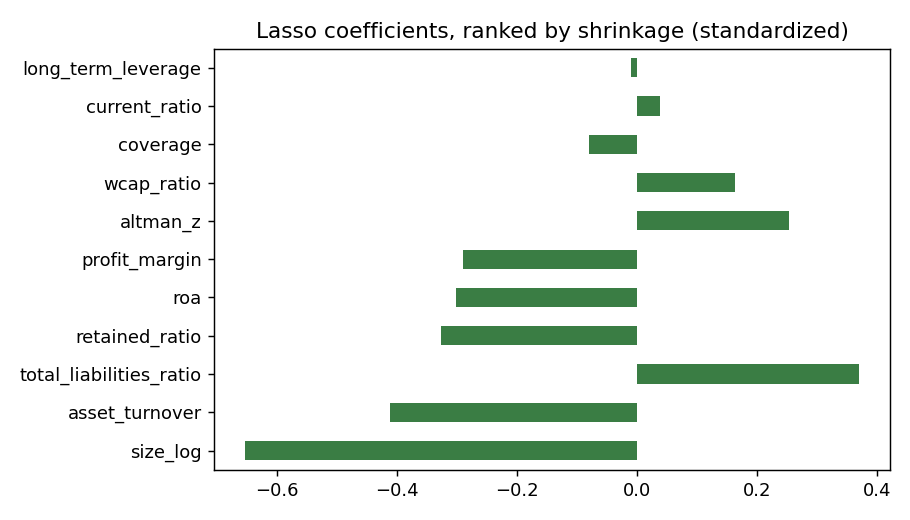

In [28]:
lasso_cv = LogisticRegressionCV(Cs=np.logspace(-3,1,30), cv=5, penalty="l1", solver="liblinear",
                                 scoring="roc_auc", max_iter=5000, random_state=42).fit(X_train_s, y_train)
coef_df = pd.Series(lasso_cv.coef_[0], index=feature_cols).sort_values(key=abs, ascending=False)
print(f"Lasso coefficients (best C={lasso_cv.C_[0]:.4f}):")
print(coef_df)
print(f"\nExact zero coefficients: {(coef_df == 0).sum()} of {len(coef_df)}")

fig, ax = plt.subplots(figsize=(7,4))
coef_df.plot(kind="barh", ax=ax, color="#3a7d44")
ax.set_title("Lasso coefficients, ranked by shrinkage (standardized)")
plt.tight_layout(); plt.savefig("figs/03_lasso_coefs.png", dpi=130); plt.show()

## Logistic Regression (Ridge, Cross Validated)

This cell uses `LogisticRegressionCV`, five fold, with an L2 (ridge)
penalty rather than Lasso's L1, fit on the training period only. Using
cross validation here rather than a single fixed value of `C` keeps this
cell consistent with the Lasso cell right above it in how rigorously its
hyperparameter is chosen, while still being meaningfully different from
Lasso in what kind of penalty it applies.

In [29]:
logit_cv = LogisticRegressionCV(Cs=np.logspace(-3,3,20), cv=5, penalty="l2", solver="lbfgs",
                                 scoring="roc_auc", max_iter=5000, class_weight="balanced",
                                 random_state=42).fit(X_train_s, y_train)
proba_logit = logit_cv.predict_proba(X_test_s)[:,1]
pred_logit = logit_cv.predict(X_test_s)
auc_logit = roc_auc_score(y_test, proba_logit)
print(f"Best C (cross validated): {logit_cv.C_[0]:.4f}")
print(f"AUC: {auc_logit:.3f}  Accuracy: {accuracy_score(y_test,pred_logit):.3f}  F1: {f1_score(y_test,pred_logit):.3f}")

cm = confusion_matrix(y_test, pred_logit)
tn, fp, fn, tp = cm.ravel()
print(f"Confusion matrix: TN={tn:,} FP={fp:,} FN={fn:,} TP={tp:,}")
print(f"Precision: {tp/(tp+fp):.3f}  Recall: {tp/(tp+fn):.3f}")

Best C (cross validated): 0.0183
AUC: 0.749  Accuracy: 0.782  F1: 0.319
Confusion matrix: TN=8,941 FP=2,186 FN=475 TP=622
Precision: 0.222  Recall: 0.567


## Support Vector Machine (Tuned)

`C` and `gamma` are chosen by a small grid search rather than left at
sklearn defaults, consistent with how the other tuned models in this
section are handled.

**A limitation worth stating plainly:** RBF kernel SVMs scale poorly
with training set size, so both the grid search and the final fit below
run on a stratified subsample of 8,000 rows drawn from the training
period rather than the full training set. The result should be read as
a tuned benchmark for comparison against the other models, not as a
candidate for the final model, since it never sees the full training
data the other models are fit on.

In [30]:
strat_idx, _ = train_test_split(np.arange(len(y_train)), train_size=8000, stratify=y_train, random_state=42)

svm_grid = GridSearchCV(
    SVC(kernel="rbf", probability=True, class_weight="balanced"),
    param_grid={"C": [0.1, 1, 10], "gamma": ["scale", 0.01, 0.1]},
    scoring="roc_auc", cv=3, n_jobs=-1,
)
svm_grid.fit(X_train_s[strat_idx], y_train[strat_idx])
svm = svm_grid.best_estimator_
print(f"Best SVM params: {svm_grid.best_params_}")

proba_svm = svm.predict_proba(X_test_s)[:,1]
pred_svm = svm.predict(X_test_s)
auc_svm = roc_auc_score(y_test, proba_svm)
print(f"AUC: {auc_svm:.3f}  Accuracy: {accuracy_score(y_test,pred_svm):.3f}  F1: {f1_score(y_test,pred_svm):.3f}")

cm = confusion_matrix(y_test, pred_svm)
tn, fp, fn, tp = cm.ravel()
print(f"Confusion matrix: TN={tn:,} FP={fp:,} FN={fn:,} TP={tp:,}")
print(f"Precision: {tp/(tp+fp):.3f}  Recall: {tp/(tp+fn):.3f}")

Best SVM params: {'C': 0.1, 'gamma': 'scale'}
AUC: 0.804  Accuracy: 0.773  F1: 0.346
Confusion matrix: TN=8,722 FP=2,405 FN=365 TP=732
Precision: 0.233  Recall: 0.667


## Random Forest (Tuned, with Permutation Importance)

`max_depth` and `min_samples_leaf` are chosen by a small grid search
rather than picked by hand, consistent with the other tuned models in
this section.

A separate methodological point concerns how feature importance is
measured. The `feature_importances_` sklearn reports by default is the
mean decrease in impurity (MDI), which is a known biased measure when
features are correlated with each other. Two ratios that carry similar
information will split that importance between them, or let one mask
the other, which can make a genuinely useful predictor look weak purely
because it has a correlated twin in the feature set, not because it
lacks signal. Our correlation heatmap in Cell 12 already showed
`current_ratio` and `altman_z` at 0.97 and `long_term_leverage` and
`total_liabilities_ratio` at 0.59, so this is not a hypothetical concern
for this specific feature set. Permutation importance, computed by
shuffling one column at a time and measuring how much the score actually
drops, is less sensitive to this and is reported alongside MDI so the
two can be compared directly rather than trusting either one blindly.

**Permutation importance is computed on the validation set, not the
test set.** The test set is reserved for the single, final, untouched
performance number reported later in this section; using it here as
well, for an exploratory diagnostic rather than a final metric, would
mean it is no longer a clean, one time check. The validation set, held
out from fitting but not from this kind of inspection, is the
appropriate place for this.

The grid below is deliberately small (`n_estimators=150` during the
search itself, two values per parameter, two fold cross validation),
since a full grid at 400 trees would take a long time on a single core;
the winning combination is then refit once at 400 trees for the actual
model used everywhere else in this section.

Best Random Forest params: {'max_depth': 10, 'min_samples_leaf': 50}
AUC: 0.811  Accuracy: 0.813  F1: 0.366
Confusion matrix: TN=9,276 FP=1,851 FN=437 TP=660
Precision: 0.263  Recall: 0.602

MDI (impurity based) importance:
retained_ratio             0.181159
size_log                   0.169231
roa                        0.154101
profit_margin              0.127073
coverage                   0.089074
total_liabilities_ratio    0.058035
wcap_ratio                 0.057179
altman_z                   0.053660
asset_turnover             0.048576
long_term_leverage         0.033314
current_ratio              0.028597
dtype: float64

Permutation importance (mean AUC drop, validation set):
size_log                   0.037575
roa                        0.030584
profit_margin              0.030130
total_liabilities_ratio    0.022008
coverage                   0.019558
retained_ratio             0.016123
asset_turnover             0.011572
long_term_leverage         0.005069
wcap_ratio          

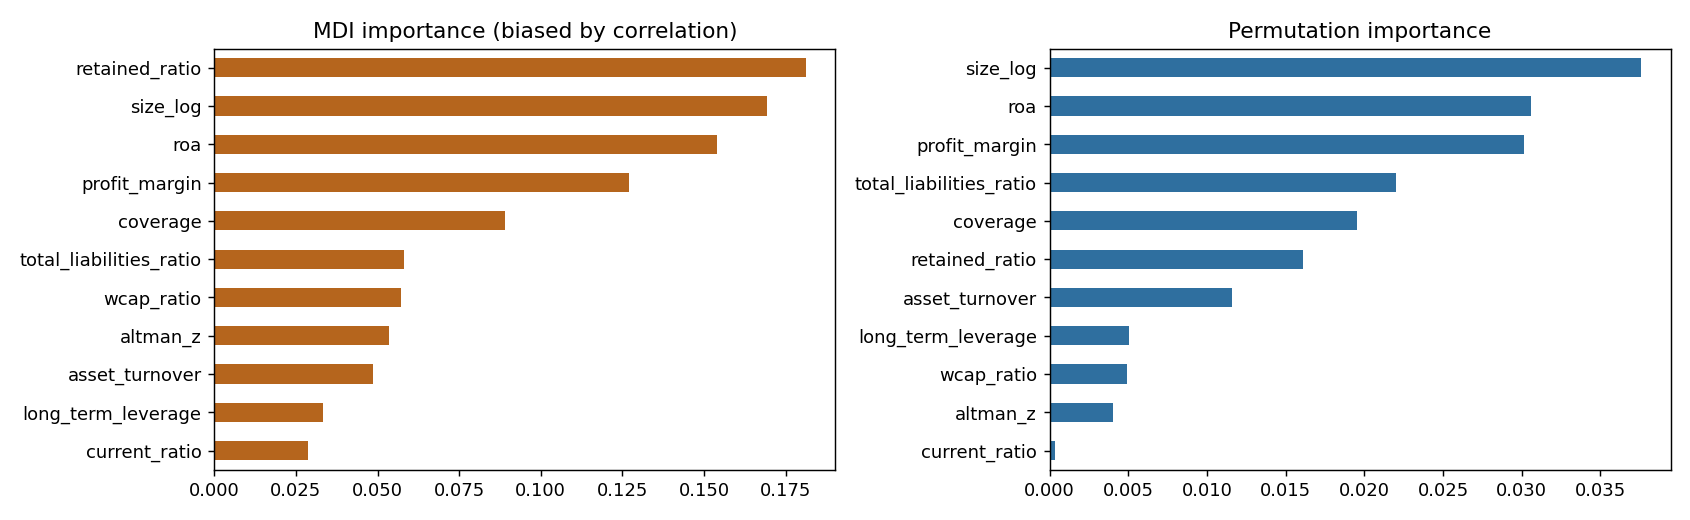

In [31]:
rf_grid = GridSearchCV(
    RandomForestClassifier(n_estimators=150, class_weight="balanced", random_state=42),
    param_grid={"max_depth": [5, 10], "min_samples_leaf": [20, 50]},
    scoring="roc_auc", cv=2,
)
rf_grid.fit(X_train.values, y_train)
print(f"Best Random Forest params: {rf_grid.best_params_}")

rf = RandomForestClassifier(n_estimators=400, class_weight="balanced", random_state=42,
                             **rf_grid.best_params_).fit(X_train.values, y_train)

proba_rf = rf.predict_proba(X_test.values)[:,1]
pred_rf = rf.predict(X_test.values)
auc_rf = roc_auc_score(y_test, proba_rf)
print(f"AUC: {auc_rf:.3f}  Accuracy: {accuracy_score(y_test,pred_rf):.3f}  F1: {f1_score(y_test,pred_rf):.3f}")

cm = confusion_matrix(y_test, pred_rf)
tn, fp, fn, tp = cm.ravel()
print(f"Confusion matrix: TN={tn:,} FP={fp:,} FN={fn:,} TP={tp:,}")
print(f"Precision: {tp/(tp+fp):.3f}  Recall: {tp/(tp+fn):.3f}")

mdi_importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

perm_result = permutation_importance(rf, X_val.values, y_val, n_repeats=10,
                                      random_state=42, scoring="roc_auc")
perm_importances = pd.Series(perm_result.importances_mean, index=feature_cols).sort_values(ascending=False)

print("\nMDI (impurity based) importance:")
print(mdi_importances)
print("\nPermutation importance (mean AUC drop, validation set):")
print(perm_importances)

fig, axes = plt.subplots(1, 2, figsize=(13,4))
mdi_importances.plot(kind="barh", ax=axes[0], color="#b5651d")
axes[0].invert_yaxis(); axes[0].set_title("MDI importance (biased by correlation)")
perm_importances.plot(kind="barh", ax=axes[1], color="#2f6f9f")
axes[1].invert_yaxis(); axes[1].set_title("Permutation importance")
plt.tight_layout(); plt.savefig("figs/04_rf_importance.png", dpi=130); plt.show()

## Neural Network (Deep Learning)

A small MLP (32 to 16 to 1, with dropout) trained with class weighted
binary cross entropy, kept shallow given only 11 input features. This
is the deep learning representative of the supervised learning block:
the mission template's own checklist lists "Neural network (regression
or classification)" as one of the options under Supervised Learning
specifically, rather than as a separate fourth block, so it stays here
structurally rather than under its own heading, while the heading itself
now says plainly what kind of model it is.

The validation data passed to `fit` is the same time based validation
set (`fyear` 2015 to 2016) used for permutation importance above, rather
than Keras carving out its own random 20% slice from the training data.
Keeping one consistent validation definition across every model in this
section, rather than a different ad hoc validation split for each model
that happens to need one, makes the validation based choices comparable
to each other.

In [32]:
tf.random.set_seed(42)
nn = keras.Sequential([
    layers.Input(shape=(X_train_s.shape[1],)),
    layers.Dense(32, activation="relu"), layers.Dropout(0.3),
    layers.Dense(16, activation="relu"), layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
])
nn.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=["AUC"])
class_weight = {0:1.0, 1:(1-y_train.mean())/y_train.mean()}
history = nn.fit(X_train_s, y_train, validation_data=(X_val_s, y_val),
                  epochs=40, batch_size=128, class_weight=class_weight, verbose=0)
proba_nn = nn.predict(X_test_s, verbose=0).flatten()
pred_nn = (proba_nn>0.5).astype(int)
auc_nn = roc_auc_score(y_test, proba_nn)
print(f"AUC: {auc_nn:.3f}  Accuracy: {accuracy_score(y_test,pred_nn):.3f}  F1: {f1_score(y_test,pred_nn):.3f}")

cm = confusion_matrix(y_test, pred_nn)
tn, fp, fn, tp = cm.ravel()
print(f"Confusion matrix: TN={tn:,} FP={fp:,} FN={fn:,} TP={tp:,}")
print(f"Precision: {tp/(tp+fp):.3f}  Recall: {tp/(tp+fn):.3f}")

AUC: 0.807  Accuracy: 0.736  F1: 0.330
Confusion matrix: TN=8,195 FP=2,932 FN=301 TP=796
Precision: 0.214  Recall: 0.726


## Model Comparison

The Evaluation Strategy section promised two baselines: the classical
Altman Z score, and a "predict majority class" baseline implied by the
8.7% base rate. Both are computed here for the first time and placed in
the same table as the four trained models, so "outperforming the
baseline" is something this notebook actually shows rather than only
states as an intention.

`altman_z` is used directly as a continuous score (no fitting involved,
since it is a fixed formula) to compute its own AUC; for accuracy and
F1, a firm is classified as distressed if its Altman Z score falls below
the conventional distress cutoff of 1.8. The majority class baseline
predicts "healthy" for every firm, which by construction gets an AUC of
0.5, the accuracy implied by the base rate, and an F1 of 0, since it
never predicts the positive class at all.

In [33]:
baseline_altman_proba = -df.loc[test_mask, "altman_z"].values  # lower Z = higher distress risk
baseline_altman_auc = roc_auc_score(y_test, baseline_altman_proba)
baseline_altman_pred = (df.loc[test_mask, "altman_z"].values < 1.8).astype(int)

baseline_majority_pred = np.zeros_like(y_test)

results = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM (RBF)", "Random Forest", "Neural Network",
              "Baseline: Altman Z score", "Baseline: predict majority class"],
    "AUC": [auc_logit, auc_svm, auc_rf, auc_nn, baseline_altman_auc, 0.5],
    "Accuracy": [accuracy_score(y_test,pred_logit), accuracy_score(y_test,pred_svm),
                 accuracy_score(y_test,pred_rf), accuracy_score(y_test,pred_nn),
                 accuracy_score(y_test, baseline_altman_pred), accuracy_score(y_test, baseline_majority_pred)],
    "F1": [f1_score(y_test,pred_logit), f1_score(y_test,pred_svm),
           f1_score(y_test,pred_rf), f1_score(y_test,pred_nn),
           f1_score(y_test, baseline_altman_pred), f1_score(y_test, baseline_majority_pred)],
}).sort_values("AUC", ascending=False)
print(results.to_string(index=False))

                           Model      AUC  Accuracy       F1
                   Random Forest 0.810934  0.812827 0.365854
                  Neural Network 0.806706  0.735520 0.329948
                       SVM (RBF) 0.804242  0.773397 0.345772
             Logistic Regression 0.748621  0.782313 0.318566
        Baseline: Altman Z score 0.572793  0.591378 0.185554
Baseline: predict majority class 0.500000  0.910259 0.000000


## Default Versus Tuned Hyperparameters

The comparison above uses the tuned version of every model. This cell
isolates the actual value of that tuning by refitting SVM and Random
Forest at their sklearn default hyperparameters, on the same data, and
comparing default against tuned side by side. Lasso and the ridge
logistic regression are both already chosen by cross validation rather
than a single fixed value, so there is no meaningful untuned version of
either to compare against; the Neural Network's architecture is fixed by
design rather than grid searched, so it is also left out of this
specific comparison.

In [34]:
svm_default = SVC(kernel="rbf", probability=True, class_weight="balanced",
                   C=1.0, gamma="scale", random_state=42).fit(X_train_s[strat_idx], y_train[strat_idx])
proba_svm_default = svm_default.predict_proba(X_test_s)[:,1]
auc_svm_default = roc_auc_score(y_test, proba_svm_default)

rf_default = RandomForestClassifier(class_weight="balanced", random_state=42).fit(X_train.values, y_train)
proba_rf_default = rf_default.predict_proba(X_test.values)[:,1]
auc_rf_default = roc_auc_score(y_test, proba_rf_default)

tuning_comparison = pd.DataFrame({
    "Model": ["SVM (RBF)", "Random Forest"],
    "AUC (default)": [auc_svm_default, auc_rf_default],
    "AUC (tuned)": [auc_svm, auc_rf],
    "AUC gain from tuning": [auc_svm - auc_svm_default, auc_rf - auc_rf_default],
})
print(tuning_comparison.round(4).to_string(index=False))

        Model  AUC (default)  AUC (tuned)  AUC gain from tuning
    SVM (RBF)         0.7878       0.8042                0.0165
Random Forest         0.7925       0.8109                0.0185


## ROC and Precision Recall Curves

ROC curves are included for comparability with standard reporting, but
with only an 8.7% positive rate, ROC AUC can look reassuring even when a
model's precision is poor, since the metric is dominated by the large
pool of true negatives that are easy to get right. The precision and recall
curve next to it is the more honest picture for a rare event problem
like this one: it shows directly how much precision has to be given up
to reach a given level of recall, with no large true negative pool to
flatter the score.

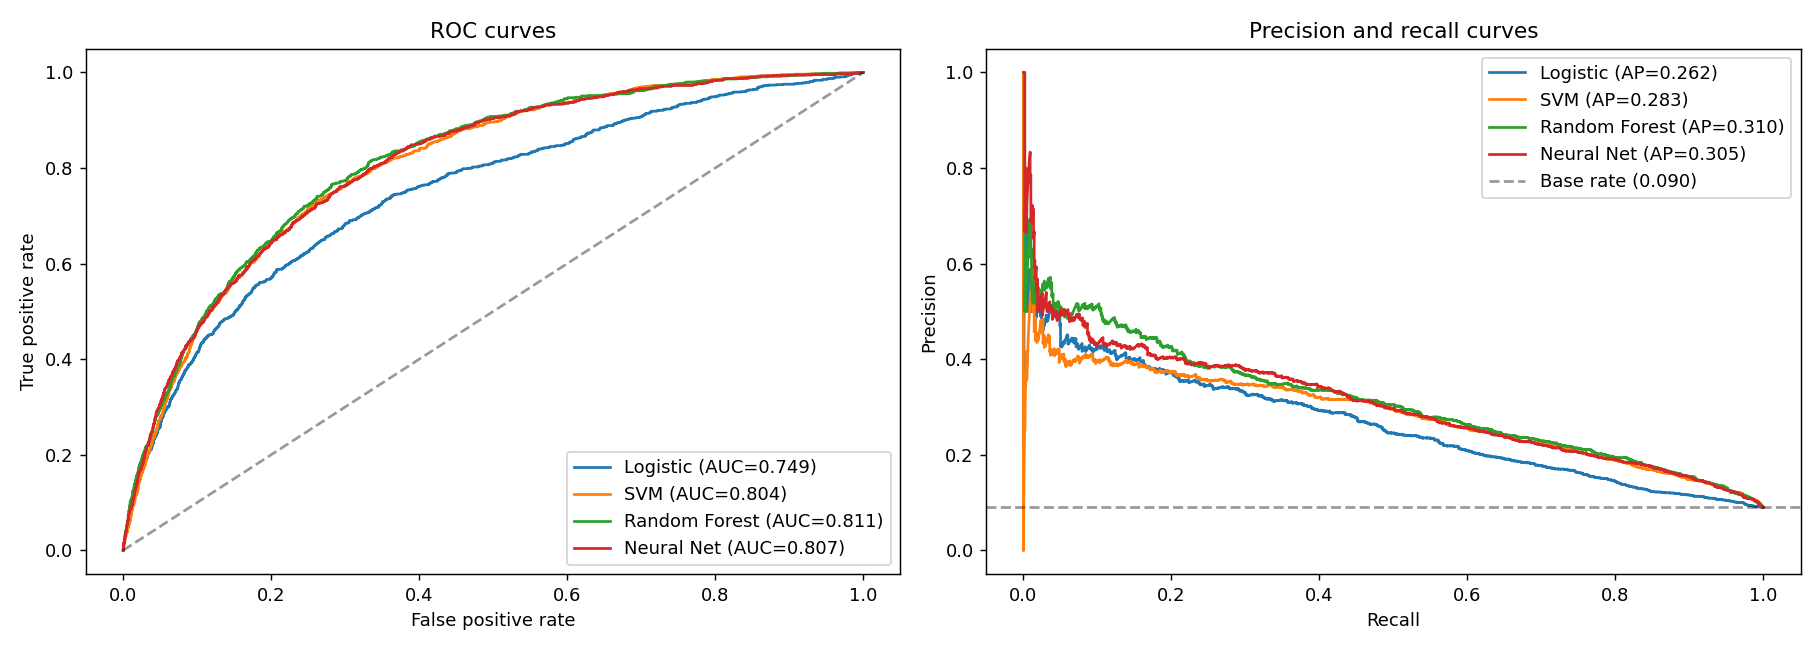

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
for name, proba in [("Logistic",proba_logit),("SVM",proba_svm),("Random Forest",proba_rf),("Neural Net",proba_nn)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test,proba):.3f})")
axes[0].plot([0,1],[0,1],"k--",alpha=0.4)
axes[0].legend(); axes[0].set_title("ROC curves")
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")

for name, proba in [("Logistic",proba_logit),("SVM",proba_svm),("Random Forest",proba_rf),("Neural Net",proba_nn)]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(rec, prec, label=f"{name} (AP={ap:.3f})")
axes[1].axhline(y_test.mean(), color="k", linestyle="--", alpha=0.4, label=f"Base rate ({y_test.mean():.3f})")
axes[1].legend(); axes[1].set_title("Precision and recall curves")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
plt.tight_layout(); plt.savefig("figs/06_roc.png", dpi=130); plt.show()

## Confusion Matrices (Side by Side Comparison)

Each model's confusion matrix and precision/recall were already printed
right after that model was trained above; this cell exists only to put
all four side by side for a single visual comparison, not to introduce
new numbers.

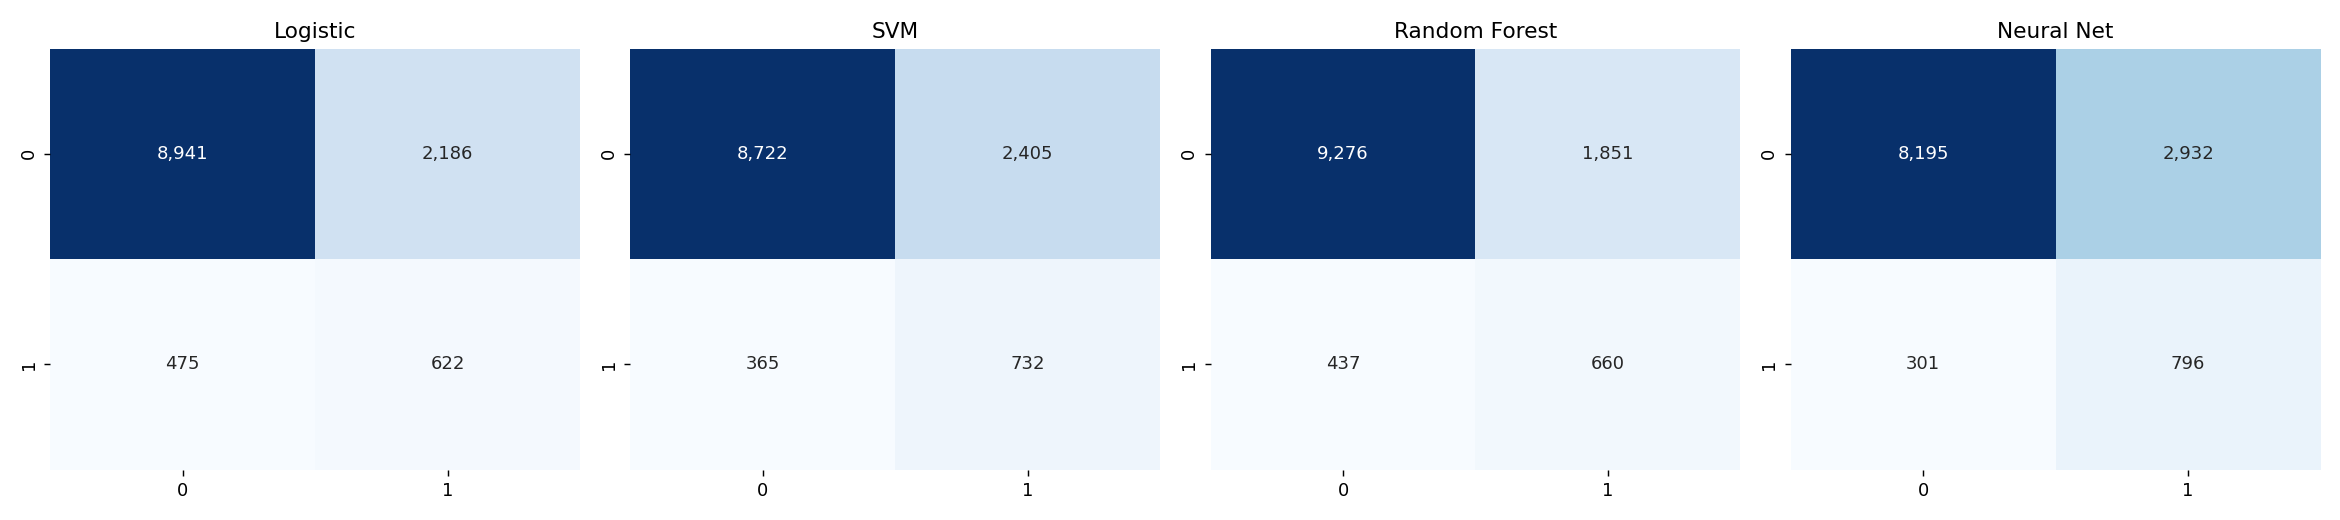

In [36]:
fig, axes = plt.subplots(1,4,figsize=(18,4))
for ax,(name,pred) in zip(axes, [("Logistic",pred_logit),("SVM",pred_svm),("Random Forest",pred_rf),("Neural Net",pred_nn)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", ax=ax, cbar=False)
    ax.set_title(name)
plt.tight_layout(); plt.savefig("figs/07_confusion.png", dpi=130); plt.show()

### 7c. Unsupervised / Generative

## Unsupervised: PCA + KMeans Firm Segmentation
This ignores the label entirely; clusters are formed purely from ratio
similarity. Worth reading carefully: cluster 0 has the *highest* leverage
(`long_term_leverage` 0.318, `total_liabilities_ratio` 0.627) but the
*lowest* distress rate of the three (6.2%). Cluster 1 has the lowest
leverage (0.021/0.232) and a moderate distress rate (9.1%). **Cluster 2**,
moderate leverage (0.124/0.502) but the weakest Altman Z score (2.742,
versus 1.675 and 5.170 for the other two), has the *highest* distress
rate of all three (11.5%). This isn't a contradiction of the causal
result above; clusters form on *all* features jointly, so leverage
alone doesn't determine risk ranking. A cluster's overall financial
health (captured here by Altman Z) matters more than leverage in
isolation, and is a good illustration of exactly why the causal section
controls for confounders explicitly, rather than reading raw group
averages at face value.

         long_term_leverage  total_liabilities_ratio  ...  altman_z  distress
cluster                                               ...                    
0                     0.318                    0.627  ...     1.675     0.062
1                     0.021                    0.232  ...     5.170     0.091
2                     0.124                    0.502  ...     2.742     0.115

[3 rows x 12 columns]


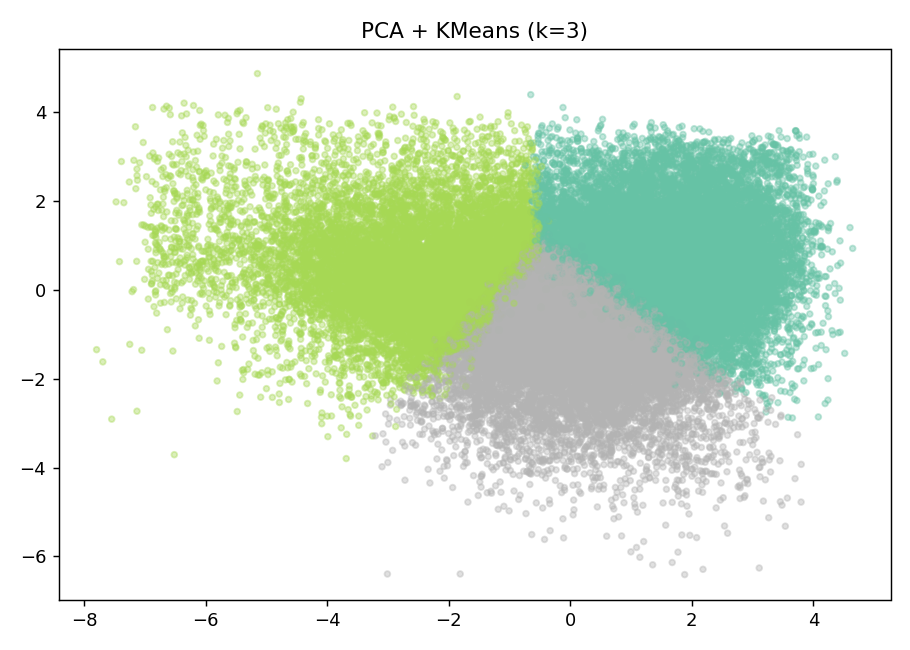

In [37]:
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_train_s)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_train_s)
clusters = kmeans.labels_
profile = pd.DataFrame(X_train.values, columns=feature_cols)
profile["cluster"] = clusters
profile["distress"] = y_train
print(profile.groupby("cluster")[feature_cols+["distress"]].mean().round(3))

fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(pcs[:,0], pcs[:,1], c=clusters, cmap="Set2", alpha=0.4, s=10)
ax.set_title("PCA + KMeans (k=3)")
plt.tight_layout(); plt.savefig("figs/05_pca_kmeans.png", dpi=130); plt.show()

## 8. Discussion & Conclusion

**Data issues identified and handled:**
- Historical industry classification (`sich`) used instead of only the current `sic`
- Negative current assets, negative revenue, and EBIT > EBITDA violations dropped
- Fiscal year end change "stub period" years excluded (628 transition years; firms kept)
- Extreme asset jumps from one year to the next flagged for transparency (4,646 firm years; kept by default)
- `ceq` not silently imputed; dropped if missing, since it drives the label
- Winsorization computed using training data only, applied to test data with the same bounds; no look ahead leakage
- Distress label excludes already distressed firm years (persistence fix); 85.6% of raw positives were persistence, now removed
- Leverage feature naming kept explicit and unambiguous (`long_term_leverage` vs. `total_liabilities_ratio`)
- `costat` investigated and deliberately excluded from the label, with the reasoning documented

**Final sample:** 66,580 firm years, 8,508 unique firms, 2000 to 2021, 8.7% genuine distress transition rate.

**Synthesis across the three method blocks:**
- **Causal inference** reveals what raw correlation hides: leverage's effect on distress flips sign once size and profitability are controlled for (naive -0.40 to adjusted +0.83). `coverage` and `total_liabilities_ratio` are deliberately excluded from the formal adjustment set, since both are mechanically entangled with leverage itself rather than independent causes of it; a DAG is a falsifiable claim about what causes what, not a formality, and these two variables do not hold up to that scrutiny. The result holds up under firm fixed effects (which absorb every unmeasured, unchanging firm trait at once) and under a placebo treatment refuter, but a sensitivity analysis is equally honest in the other direction: a hidden confounder no stronger than firm size itself, our strongest *named* confounder, would be enough to flip the sign. This is the clearest single finding of the project and is the kind of relationship neither the supervised nor unsupervised blocks alone would have surfaced, since both treat leverage as just another input feature without disentangling cause from confound; it is also the finding most honestly hedged by what we cannot rule out.
- **Supervised learning**, evaluated on a genuinely out of time test period (`fyear` 2017 onward, never seen during fitting) rather than a random split, shows Random Forest still on top (AUC 0.811), with the Neural Network (0.807) and the tuned SVM (0.804) close behind, and Logistic Regression clearly last (0.749); all four clear both stated baselines by a wide margin (Altman Z score 0.573, predict majority class 0.500). The dedicated default versus tuned comparison shows tuning was not a cosmetic step: it gained 0.017 AUC for SVM and 0.019 for Random Forest, a meaningful share of the total gap between the strongest and weakest models. Random Forest's own feature importances tell two different stories depending on which measure is read and where it is measured: the default MDI ranking (on the training data the model was fit on) puts `retained_ratio` first, but permutation importance (measured on the validation set, less sensitive to correlation between features) drops `retained_ratio` to sixth and moves `size_log` up to first, a direct, visible example of MDI's known bias under correlated inputs rather than a hypothetical concern. Both measures agree, though, that `total_liabilities_ratio` carries more predictive weight than `long_term_leverage` specifically (Lasso: 0.371 vs 0.011 in magnitude; permutation importance: 0.022 vs 0.005), which is the one comparison this nuances the causal finding with: leverage causally raises risk, but *total* liabilities, not long term debt specifically, are the stronger *predictive* signal.
- **Unsupervised learning** (PCA + KMeans) shows that leverage alone does not by itself determine the ranking of firm risk: the cluster with the highest leverage has the *lowest* distress rate, because it's also the cluster with the highest overall quality on every other dimension (Altman Z). This is consistent with, not contradictory to, the causal result; it's a reminder that raw group comparisons (which the unsupervised lens naturally invites) conflate the same confounders the causal section explicitly controls for.

Together, the three lenses tell a coherent story: leverage matters causally, but in the raw data its effect is masked by who tends to carry it; once you account for who, leverage's danger emerges again, and yet for the practical task of predicting which firms will get into trouble, broader liability and profitability ratios carry more weight than long term debt alone.

**Limitations:**
- The label is a constructed proxy in the style of Altman and Dichev (1998), not a verified bankruptcy filing. Merging the LoPucki Bankruptcy Research Database or CRSP delisting codes by `gvkey` would let the label distinguish true bankruptcy from other reasons firms exit the universe of firms Compustat marks as active via `costat` (acquisition, going private), and would be the strongest possible next step with more time.
- The extreme asset jump flag (Cell 6) was deliberately left in the modelling sample rather than excluded by default, since these could be real distress driven by M&A cases, not noise. A simple robustness check, rerunning the pipeline with that flag's rows excluded, would directly address any concern about this judgment call.
- The SVM is trained on a subsample of 8,000 rows of the training set for computational reasons; an SVM trained on the full sample (e.g. via a linear kernel or method that does not require subsampling) was not attempted and could change its relative ranking slightly.
